In [49]:
import warnings; warnings.filterwarnings("ignore")
import os, sys, json, time, argparse
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns, joblib
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (cross_validate, cross_val_score,
    cross_val_predict, KFold, RandomizedSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import QuantileRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
    HuberRegressor, BayesianRidge, TheilSenRegressor, RANSACRegressor)
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR, NuSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor,
    HistGradientBoostingRegressor, StackingRegressor, VotingRegressor)
from font_setting import set_korean_font
set_korean_font()


In [50]:
# 1. 터미널 출력과 파일 출력을 동시에 수행하는 클래스
class Logger:
    def __init__(self, filename="pipeline.log"):
        self.terminal = sys.stdout
        self.log = open(filename, "a", encoding="utf-8")

    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.log.flush()  # 실시간 저장 보장

    def flush(self):
        # 파이썬의 표준 출력 요구사항을 맞추기 위한 빈 메서드
        pass
# ── XGBoost / LightGBM / CatBoost 동적 로드 ─────────────────
# 설치된 경우 실제 라이브러리 사용, 없으면 HistGBM 대안으로 fallback
def _try_import():
    res = {}
    try:
        from xgboost import XGBRegressor
        res['xgb'] = XGBRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=4, subsample=0.8,
                                   colsample_bytree=0.8, reg_lambda=1.0,
                                   random_state=42, n_jobs=-1)
        res['xgb_name'] = 'XGBoost (실제)'
    except ImportError:
        res['xgb'] = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_depth=4,
            l2_regularization=1.0, random_state=42)
        res['xgb_name'] = 'HistGBM (≈XGBoost 대안)'

    try:
        from lightgbm import LGBMRegressor
        res['lgb'] = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                    num_leaves=31, subsample=0.8,
                                    colsample_bytree=0.8, random_state=42,
                                    n_jobs=-1, verbose=-1)
        res['lgb_name'] = 'LightGBM (실제)'
    except ImportError:
        res['lgb'] = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, min_samples_leaf=10,
            l2_regularization=0.01, random_state=42)
        res['lgb_name'] = 'HistGBM (≈LightGBM 대안)'

    try:
        from catboost import CatBoostRegressor
        res['cb'] = CatBoostRegressor(iterations=300, learning_rate=0.05,
                                       depth=6, l2_leaf_reg=3.0,
                                       random_seed=42, verbose=0)
        res['cb_name'] = 'CatBoost (실제)'
    except ImportError:
        res['cb'] = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.03, max_depth=6,
            l2_regularization=3.0, min_samples_leaf=30, random_state=42)
        res['cb_name'] = 'HistGBM (≈CatBoost 대안)'

    return res

BOOST_LIBS = _try_import()


In [51]:
# ══════════════════════════════════════════════════════════════
# 전역 설정
# ══════════════════════════════════════════════════════════════
RANDOM_STATE = 0
CV_FOLDS     = 5
DATA_PATH    = "semiconductor_yield_forecasting_data.csv"
OUTPUT_DIR   = "output"
FIG_DIR      = os.path.join(OUTPUT_DIR, "figures")
RES_DIR      = os.path.join(OUTPUT_DIR, "results")
for d in [OUTPUT_DIR, FIG_DIR, RES_DIR]:
    os.makedirs(d, exist_ok=True)

PROCESS_FEATURES = [
    'etch_rate','pressure','temperature','exposure_time','focus_offset','dose',
    'deposition_rate','thickness_uniformity','implant_energy','tilt_angle',
    'critical_dimension','oxide_thickness','resistivity','defect_count',
    'defect_density','vth','leakage_current','resistance',
]
TARGET     = 'yield'
TECH_NODES = ['7nm','10nm','14nm','22nm','28nm']
NODE_COLORS= {'7nm':'#e74c3c','10nm':'#e67e22','14nm':'#f39c12','22nm':'#27ae60','28nm':'#2980b9'}
CAT_COLORS = {'linear':'#3498db','robust':'#9b59b6','nonlinear':'#e67e22',
              'tree':'#95a5a6','ensemble':'#e74c3c','boosting':'#c0392b'}
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


In [52]:
def banner(s): print(f"\n{'═'*65}\n  {s}\n{'═'*65}")
def norm(a):   r=a-a.min(); return r/(r.max()+1e-10)
def save_fig(fig, name):
    fig.savefig(os.path.join(FIG_DIR,f"{name}.png"),bbox_inches='tight',dpi=150); plt.close(fig)
    print(f"  → {name}.png")
def save_json(obj, name):
    with open(os.path.join(RES_DIR,f"{name}.json"),'w') as f: json.dump(obj,f,indent=2,default=float)
    print(f"  → {name}.json")
def save_csv(df_, name):
    df_.to_csv(os.path.join(RES_DIR,f"{name}.csv"),index=False); print(f"  → {name}.csv")
def load_json(name):
    p=os.path.join(RES_DIR,f"{name}.json")
    if os.path.exists(p):
        with open(p) as f: return json.load(f)
    return None


In [53]:
# ══════════════════════════════════════════════════════════════
# 데이터 로드 & 피처셋 A/B/C/D
# ══════════════════════════════════════════════════════════════
def load_data():
    df = pd.read_csv(DATA_PATH)
    le = LabelEncoder()
    df['tech_encoded'] = le.fit_transform(df['technology_node'])
    FS_A = PROCESS_FEATURES + ['tech_encoded']
    # B: 다중공선성 제거 (defect_density vs thickness_uniformity r=0.9996)
    FS_B = [f for f in PROCESS_FEATURES if f != 'defect_density'] + ['tech_encoded']
    # C: EDA + 피처 엔지니어링 ★ (최종 채택)
    df['is_advanced_node']    = df['technology_node'].isin(['7nm','10nm']).astype(int)
    df['defect_composite']    = (df['defect_count']*df['defect_density']).apply(np.log1p)
    df['Swing']      = df['vth']*np.log10(df['leakage_current'])
    df['IR_Drop'] = df['resistance']*(df['leakage_current'].clip(1e-10))
    df['node_x_cd']           = df['tech_encoded']*df['critical_dimension']
    FS_C = FS_B + ['is_advanced_node','defect_composite',
                   'Swing','IR_Drop','node_x_cd']
    # D: C + 추가 파생 (§8 실험)
    df['process_stability']    = (df['etch_rate']/df['etch_rate'].std()
                                 +df['deposition_rate']/df['deposition_rate'].std()
                                 +df['implant_energy']/df['implant_energy'].std())/3
    df['power_efficiency'] = df['vth']/df['resistance']/df['leakage_current'].clip(1e-10)
    df['cd_squared']           = df['critical_dimension']**2
    FS_D = FS_C + ['process_stability','power_efficiency','cd_squared']
    return df, le, {'A':FS_A,'B':FS_B,'C':FS_C,'D':FS_D}



In [80]:
print("═"*65)
print("  반도체 수율 예측 & XAI 분석 — 완전 재현 파이프라인")
print(f"  XGBoost : {BOOST_LIBS['xgb_name']}")
print(f"  LightGBM: {BOOST_LIBS['lgb_name']}")
print(f"  CatBoost: {BOOST_LIBS['cb_name']}")
print("═"*65)

print("\n▶ 데이터 로드...")
df,le,FS=load_data()
print(f"  {df.shape[0]}행 × {df.shape[1]}열  /  FS-C:{len(FS['C'])}개  FS-D:{len(FS['D'])}개")

═════════════════════════════════════════════════════════════════
  반도체 수율 예측 & XAI 분석 — 완전 재현 파이프라인
  XGBoost : HistGBM (≈XGBoost 대안)
  LightGBM: HistGBM (≈LightGBM 대안)
  CatBoost: HistGBM (≈CatBoost 대안)
═════════════════════════════════════════════════════════════════

▶ 데이터 로드...
  1250행 × 37열  /  FS-C:23개  FS-D:26개



═════════════════════════════════════════════════════════════════
  §1  EDA 심층 분석 & 피처셋 설계
═════════════════════════════════════════════════════════════════
  이분화 t-test: t=35.08, p=3.61e-188
  ANOVA:        F=307.48, p=5.53e-184
  FS-A: R²=0.6692
  FS-B: R²=0.6678
  FS-C: R²=0.6701
  FS-D: R²=0.6704


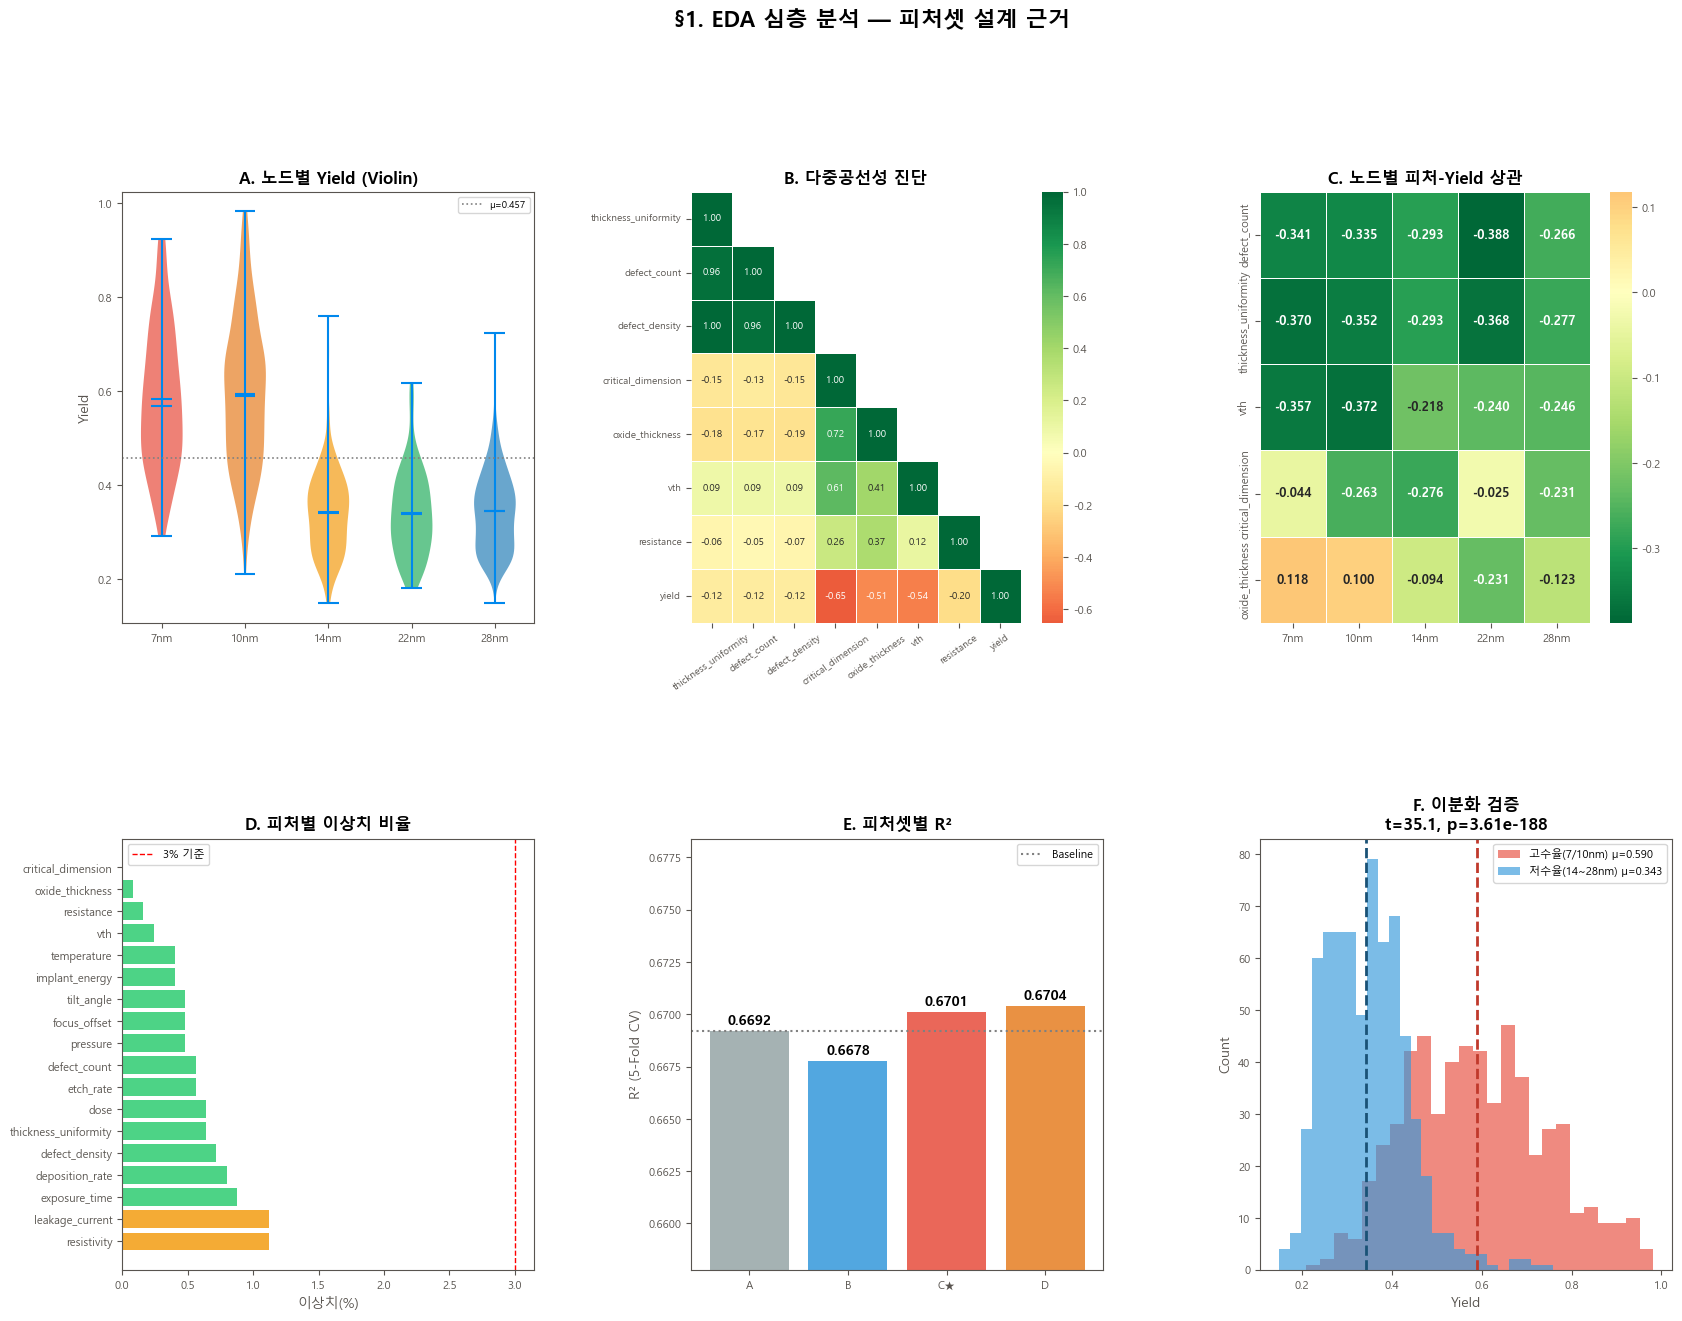

In [55]:
%matplotlib inline
banner("§1  EDA 심층 분석 & 피처셋 설계")
y = df[TARGET].values
hg=df[df['technology_node'].isin(['7nm','10nm'])][TARGET]
lg=df[df['technology_node'].isin(['14nm','22nm','28nm'])][TARGET]
t_s,t_p=stats.ttest_ind(hg,lg) #hg와 lg 두 그룹간 평군 차이를 t-test 수행
#모든 node 간 평균 차이가 있는지 ANAVA 수행
f_s,f_p=stats.f_oneway(*[df[df['technology_node']==n][TARGET].values for n in TECH_NODES]) 

print(f"  이분화 t-test: t={t_s:.2f}, p={t_p:.2e}")
print(f"  ANOVA:        F={f_s:.2f}, p={f_p:.2e}")

# 성능 비교를 위한 기준 모델을 GBM으로 설정
probe = GradientBoostingRegressor(n_estimators=100,learning_rate=0.05,
                                    max_depth=3,random_state=RANDOM_STATE)
fs_r2 = {}
# 피처셋별 K-Fold CV를 통해 R2 점수를 계산
for nm,fset in FS.items():
    r2 = float(cross_val_score(probe,df[fset].values,y,cv=kf,scoring='r2').mean())
    fs_r2[nm]=r2; print(f"  FS-{nm}: R²={r2:.4f}")

corr_m = df[PROCESS_FEATURES].corr() #공정 피처들 간의 상관계수 계산
# 상관계수가 0.8 이상인 다중공선성 추정 피처 쌍 찾기
high_corr = [(PROCESS_FEATURES[i],PROCESS_FEATURES[j],float(corr_m.iloc[i,j]))
                for i in range(len(PROCESS_FEATURES))
                for j in range(i+1,len(PROCESS_FEATURES)) if abs(corr_m.iloc[i,j])>0.8]
# IQR 방식을 사용해서 피처별 이상치 비율 계산
df_outlier = df
df_outlier['leakage_current'] = np.log10(df_outlier['leakage_current'])
outlier_pct = {f:float(((df[f]<df[f].quantile(.25)-1.5*(df[f].quantile(.75)-df[f].quantile(.25)))|
                            (df[f]>df[f].quantile(.75)+1.5*(df[f].quantile(.75)-df[f].quantile(.25)))).mean()*100)
                for f in PROCESS_FEATURES}
outlier_pct_log = {f:float(((df_outlier[f]<df_outlier[f].quantile(.25)-1.5*(df_outlier[f].quantile(.75)-df_outlier[f].quantile(.25)))|
                            (df_outlier[f]>df_outlier[f].quantile(.75)+1.5*(df_outlier[f].quantile(.75)-df_outlier[f].quantile(.25)))).mean()*100)
                for f in PROCESS_FEATURES}

fig=plt.figure(figsize=(20,14))
fig.suptitle('§1. EDA 심층 분석 — 피처셋 설계 근거',fontsize=16,fontweight='bold',y=1.01)
gs=gridspec.GridSpec(2,3,figure=fig,hspace=0.5,wspace=0.38)

#node별 yield 분포를 바이올린plot으로 표현
ax=fig.add_subplot(gs[0,0])
parts=ax.violinplot([df[df['technology_node']==n][TARGET].values for n in TECH_NODES],
                    showmeans=True,showmedians=True)
for pc,n in zip(parts['bodies'],TECH_NODES): pc.set_facecolor(NODE_COLORS[n]); pc.set_alpha(0.7)
ax.set_xticks(range(1,6)); ax.set_xticklabels(TECH_NODES,fontsize=8)
ax.set_ylabel('Yield'); ax.set_title('A. 노드별 Yield (Violin)',fontweight='bold')
ax.axhline(df[TARGET].mean(),color='gray',linestyle=':',lw=1.2,label=f'μ={df[TARGET].mean():.3f}')
ax.legend(fontsize=7)

# 다중공선성 히트맵
ax=fig.add_subplot(gs[0,1])
cols_hm=['thickness_uniformity','defect_count','defect_density',
            'critical_dimension','oxide_thickness','vth','resistance',TARGET]
mask_=np.triu(np.ones((len(cols_hm),len(cols_hm)),dtype=bool),k=1)
sns.heatmap(df[cols_hm].corr(),ax=ax,annot=True,fmt='.2f',cmap='RdYlGn',
            center=0,linewidths=0.4,annot_kws={'size':7},mask=mask_)
ax.set_title('B. 다중공선성 진단',fontweight='bold')
ax.tick_params(axis='x',rotation=35,labelsize=7); ax.tick_params(axis='y',rotation=0,labelsize=7)

# node별 피처와 yield의 상관 분석
ax=fig.add_subplot(gs[0,2])
top5=['defect_count','thickness_uniformity','vth','critical_dimension','oxide_thickness']
ch=pd.DataFrame({n:df[df['technology_node']==n][top5+[TARGET]].corr()[TARGET].drop(TARGET)
                    for n in TECH_NODES})
sns.heatmap(ch,ax=ax,annot=True,fmt='.3f',cmap='RdYlGn_r',center=0,
            linewidths=0.4,annot_kws={'size':9,'fontweight':'bold'})
ax.set_title('C. 노드별 피처-Yield 상관',fontweight='bold')

# 피처별 이상치 비율
ax=fig.add_subplot(gs[1,0])
out_s=pd.Series(outlier_pct).sort_values(ascending=False)
ax.barh(out_s.index,out_s.values,
        color=['#e74c3c' if v>3 else '#f39c12' if v>1 else '#2ecc71' for v in out_s.values],alpha=0.85)
ax.axvline(3,color='red',linestyle='--',lw=1,label='3% 기준')
ax.set_xlabel('이상치(%)'); ax.set_title('D. 피처별 이상치 비율',fontweight='bold'); ax.legend(fontsize=8)

# 피처셋별 R2 성능비교
ax=fig.add_subplot(gs[1,1])
fl=['A','B','C★','D']; fv=[fs_r2[k] for k in ['A','B','C','D']]
bars=ax.bar(fl,fv,color=['#95a5a6','#3498db','#e74c3c','#e67e22'],alpha=0.85)
ax.set_ylim(min(fv)-.01,max(fv)+.008); ax.set_ylabel('R² (5-Fold CV)')
ax.set_title('E. 피처셋별 R²',fontweight='bold')
for bar,val in zip(bars,fv):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.0003,
            f'{val:.4f}',ha='center',fontweight='bold',fontsize=10)
ax.axhline(fv[0],color='gray',linestyle=':',lw=1.5,label='Baseline'); ax.legend(fontsize=8)

# F. 이분화 검증 히스토램
ax=fig.add_subplot(gs[1,2])
ax.hist(hg,bins=25,alpha=0.65,color='#e74c3c',label=f'고수율(7/10nm) μ={hg.mean():.3f}')
ax.hist(lg,bins=25,alpha=0.65,color='#3498db',label=f'저수율(14~28nm) μ={lg.mean():.3f}')
ax.axvline(hg.mean(),color='#c0392b',linestyle='--',lw=2)
ax.axvline(lg.mean(),color='#1a5276',linestyle='--',lw=2)
ax.set_xlabel('Yield'); ax.set_ylabel('Count')
ax.set_title(f'F. 이분화 검증\nt={t_s:.1f}, p={t_p:.2e}',fontweight='bold'); ax.legend(fontsize=8)

# save_fig(fig,'sec1_eda_deep')
# save_json({'fs_r2':fs_r2,'t_stat':float(t_s),'t_p':float(t_p),'f_stat':float(f_s),
#             'f_p':float(f_p),'high_corr_pairs':high_corr,'outlier_pct':outlier_pct},'sec1_eda')

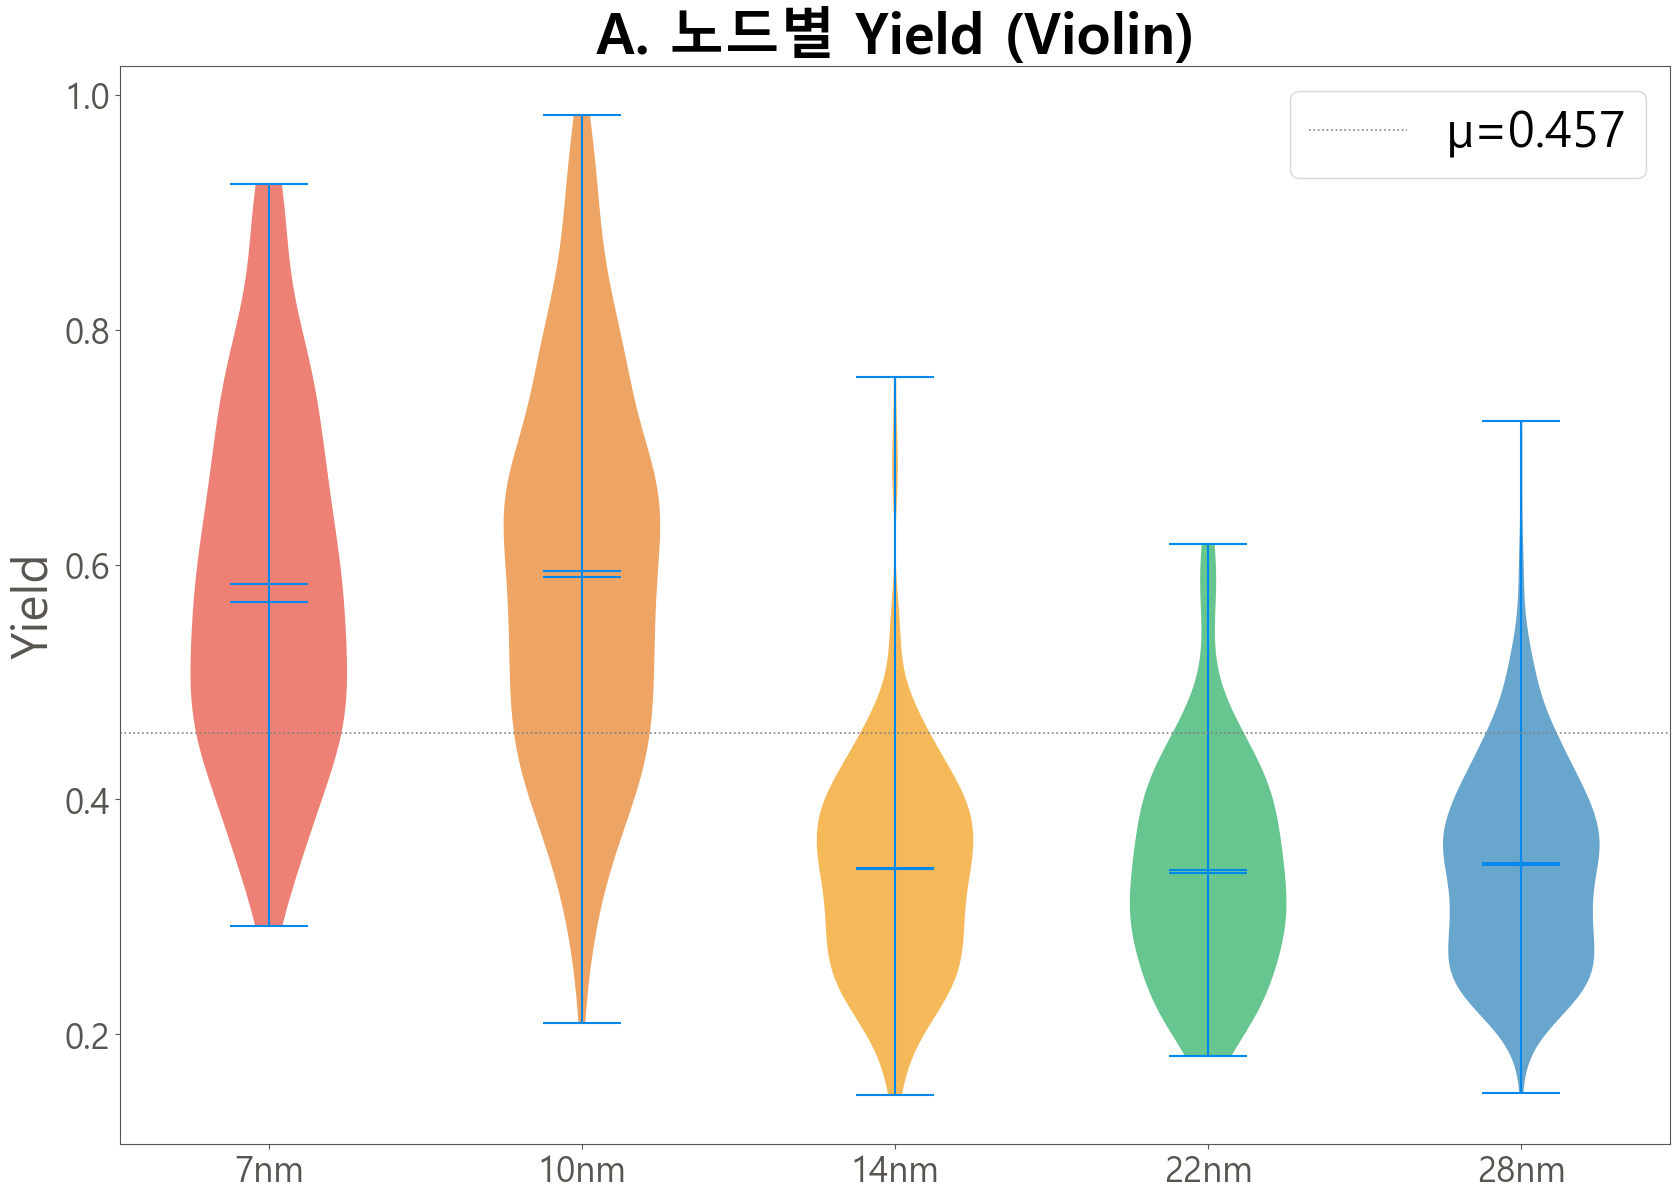

In [56]:
fig=plt.figure(figsize=(20,14))
# fig.suptitle('§1. EDA 심층 분석 — 피처셋 설계 근거',fontsize=30
            #  ,fontweight='bold',y=1.01)
gs=gridspec.GridSpec(1,1,figure=fig,hspace=0.5,wspace=0.38)

#node별 yield 분포를 바이올린plot으로 표현
ax=fig.add_subplot(gs[0,0])
parts=ax.violinplot([df[df['technology_node']==n][TARGET].values for n in TECH_NODES],
                    showmeans=True,showmedians=True)
for pc,n in zip(parts['bodies'],TECH_NODES): pc.set_facecolor(NODE_COLORS[n]); pc.set_alpha(0.7)
ax.set_xticks(range(1,6)); ax.set_xticklabels(TECH_NODES,fontsize=25)
ax.set_ylabel('Yield',fontsize=35); ax.set_title('A. 노드별 Yield (Violin)',fontweight='bold',fontsize=40)
ax.tick_params(axis='y', labelsize=25)
ax.axhline(df[TARGET].mean(),color='gray',linestyle=':',lw=1.2,label=f'μ={df[TARGET].mean():.3f}')
ax.legend(fontsize=35)

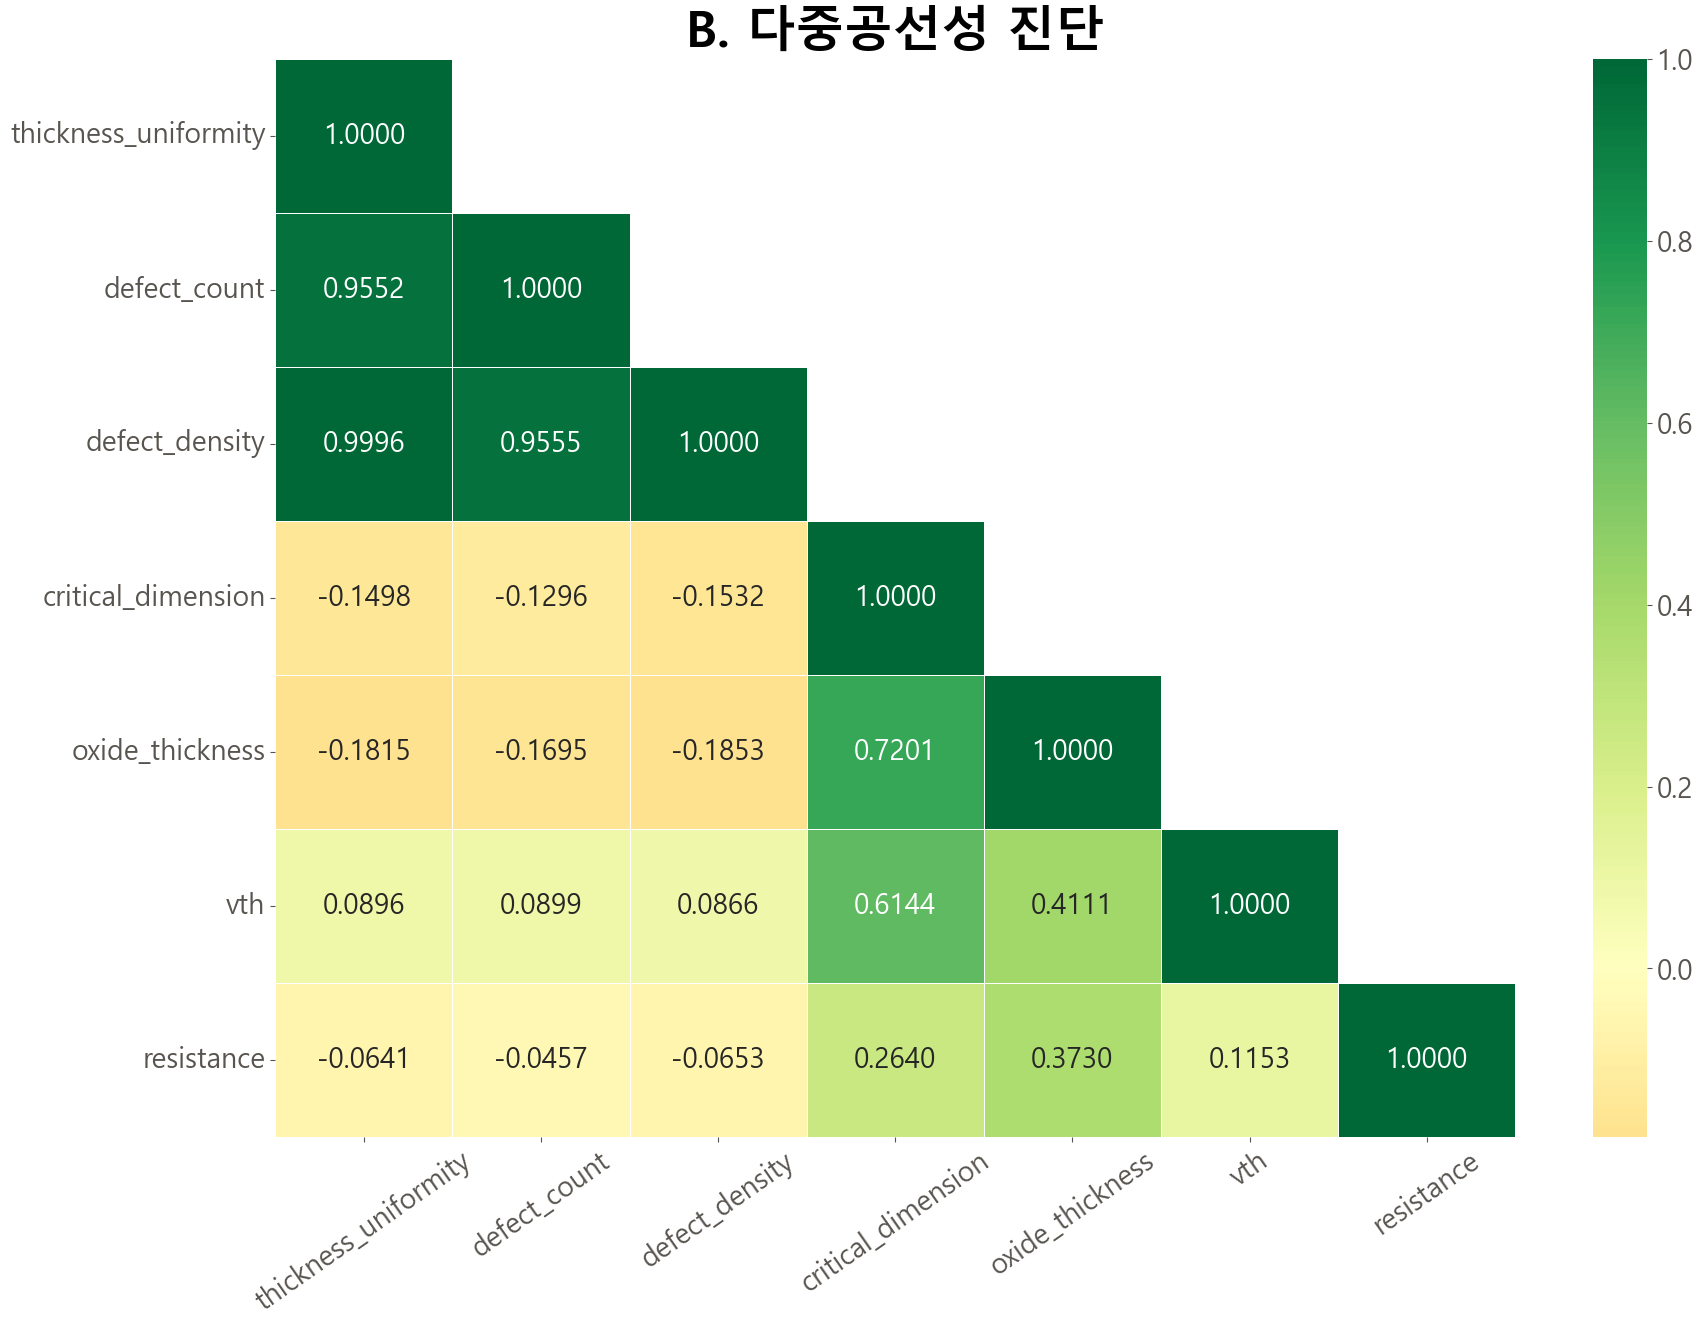

In [57]:
# 다중공선성 히트맵
from font_setting import set_korean_font
set_korean_font()
fig=plt.figure(figsize=(20,14))
gs=gridspec.GridSpec(1,1,figure=fig,hspace=0.5,wspace=0.38)

#node별 yield 분포를 바이올린plot으로 표현
ax=fig.add_subplot(gs[0,0])
cols_hm=['thickness_uniformity','defect_count','defect_density',
            'critical_dimension','oxide_thickness','vth','resistance']
mask_=np.triu(np.ones((len(cols_hm),len(cols_hm)),dtype=bool),k=1)
sns.heatmap(df[cols_hm].corr(),ax=ax,annot=True,fmt='.4f',cmap='RdYlGn',
            center=0,linewidths=0.4,annot_kws={'size':20},mask=mask_,
            )
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)  # 폰트 크기 설정
ax.set_title('B. 다중공선성 진단',fontweight='bold',fontsize=35)
ax.tick_params(axis='x',rotation=35,labelsize=20); ax.tick_params(axis='y',rotation=0,labelsize=20)

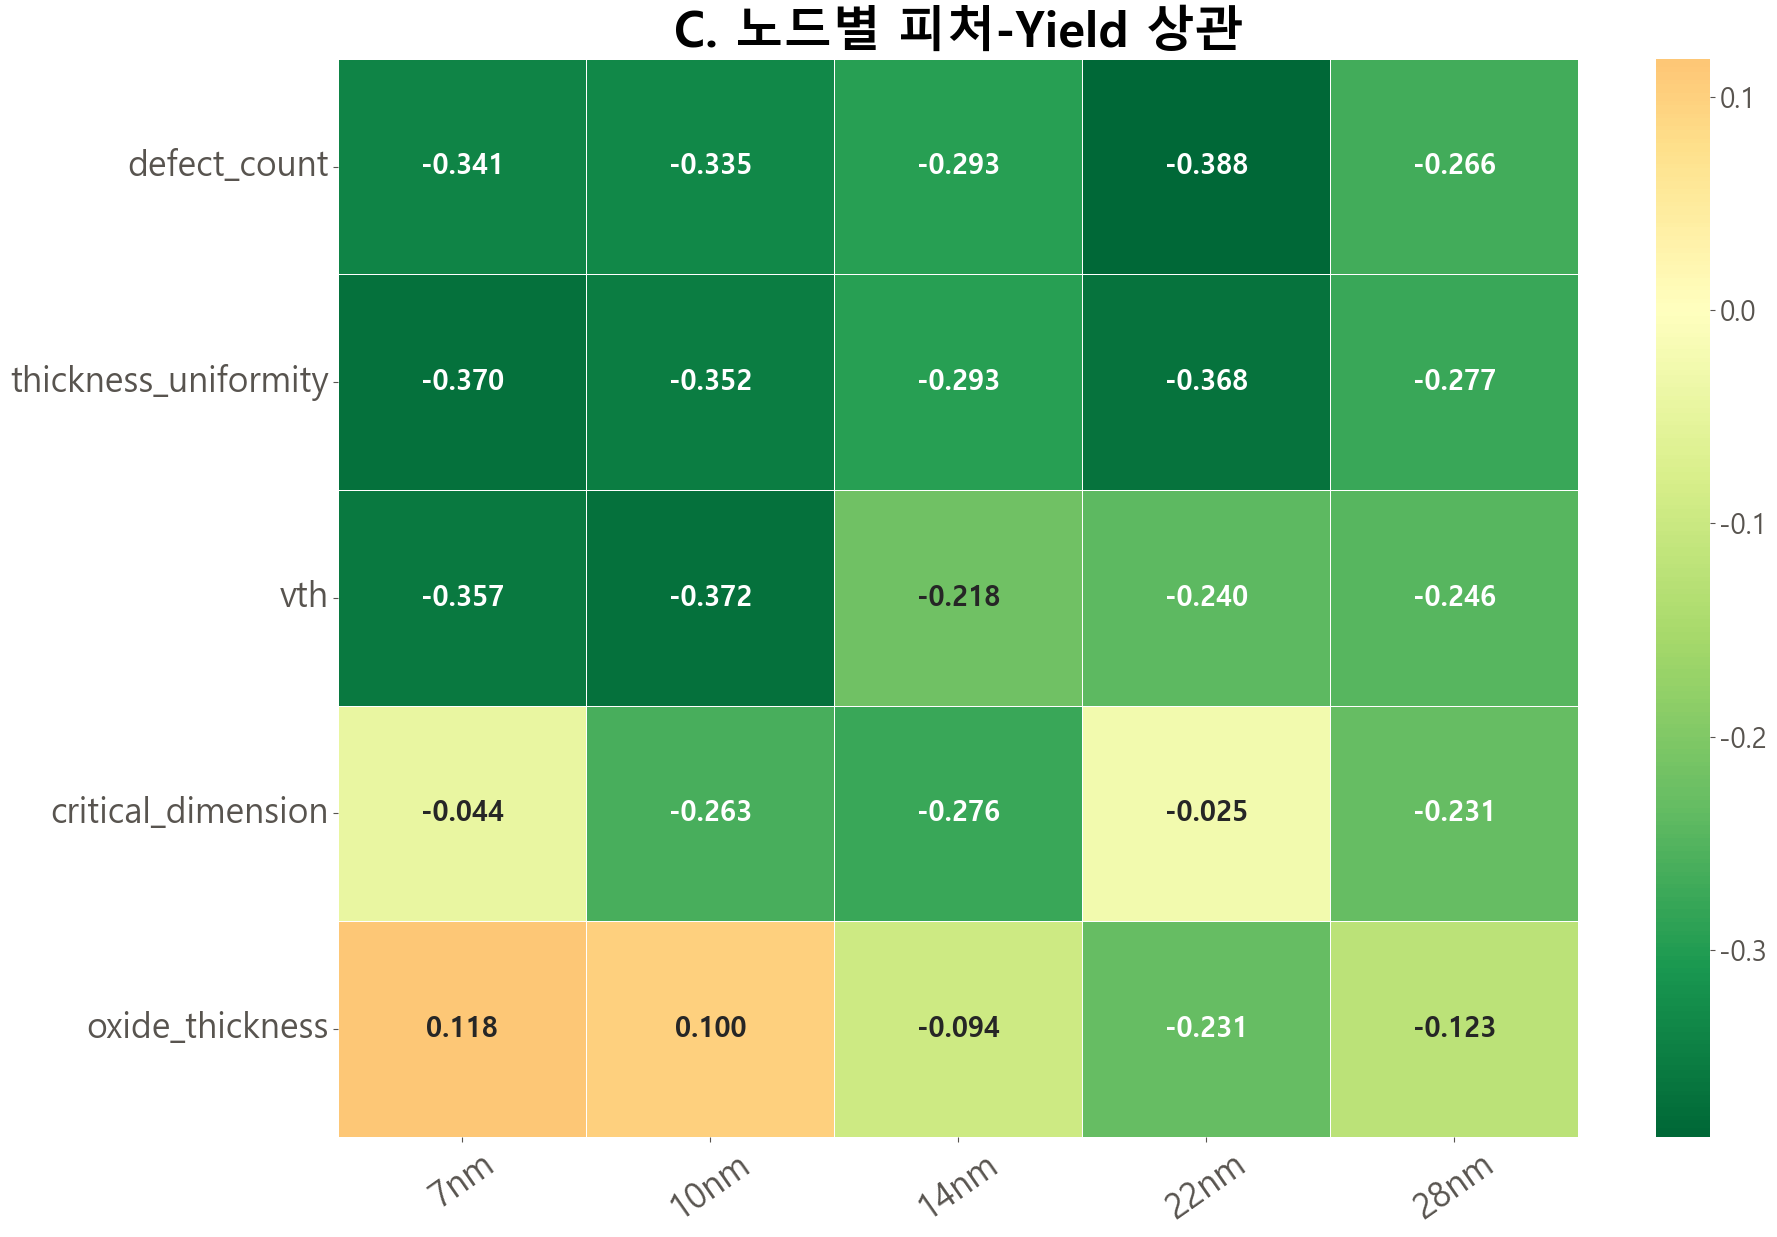

In [58]:
# node별 피처와 yield의 상관 분석
%matplotlib inline
fig=plt.figure(figsize=(20,14))
ax=fig.add_subplot(gs[0,0])
gs=gridspec.GridSpec(1,1,figure=fig,hspace=0.5,wspace=0.38)
top5=['defect_count','thickness_uniformity','vth','critical_dimension','oxide_thickness']
ch=pd.DataFrame({n:df[df['technology_node']==n][top5+[TARGET]].corr()[TARGET].drop(TARGET)
                    for n in TECH_NODES})
sns.heatmap(ch,ax=ax,annot=True,fmt='.3f',cmap='RdYlGn_r',center=0,
            linewidths=0.4,annot_kws={'size':20,'fontweight':'bold'})
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)  # 폰트 크기 설정
ax.set_title('C. 노드별 피처-Yield 상관',fontweight='bold',fontsize=35)
ax.tick_params(axis='x',rotation=35,labelsize=25); ax.tick_params(axis='y',rotation=0,labelsize=25)

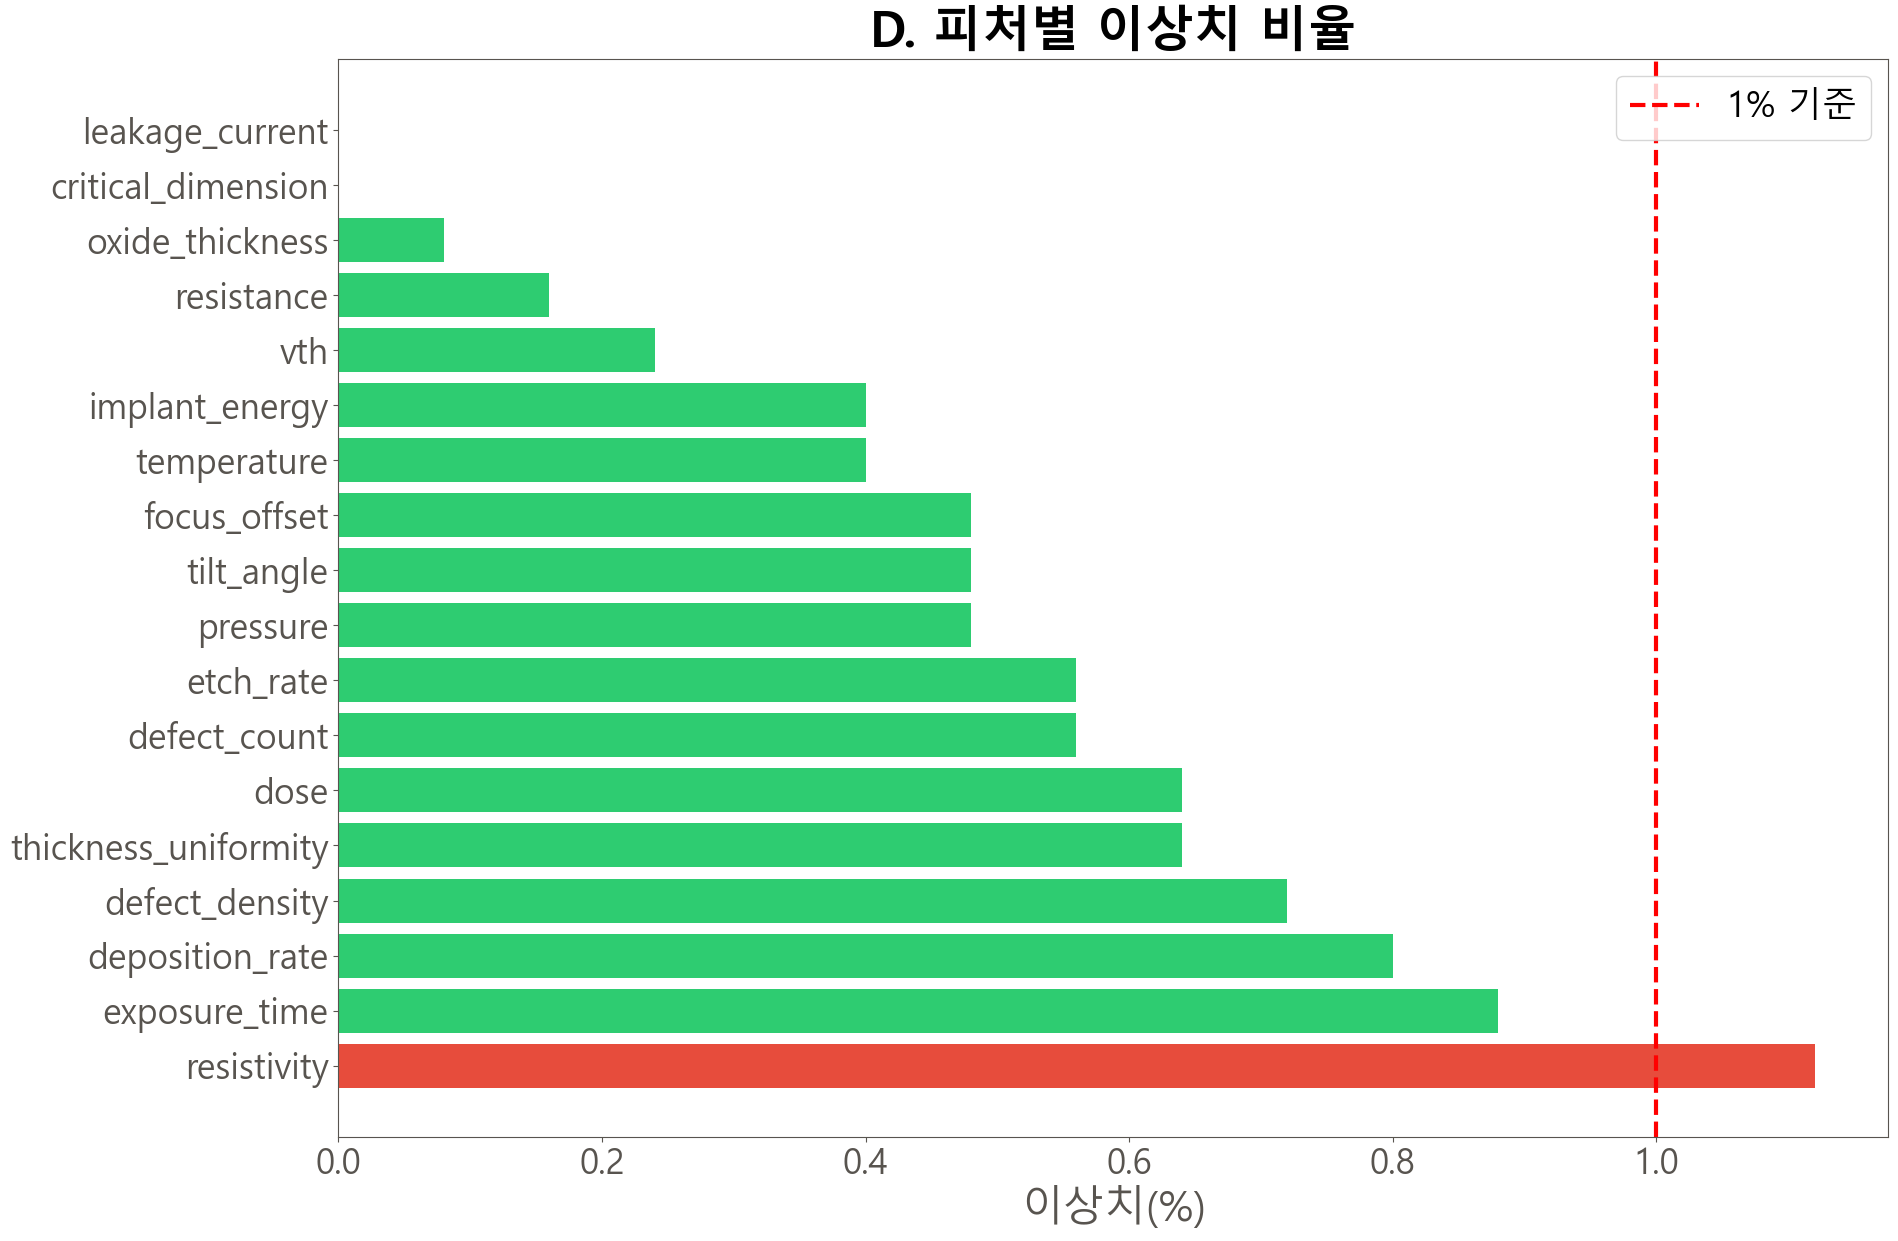

In [59]:
# IQR 방식을 사용해서 피처별 이상치 비율 계산
df_outlier = df
df_outlier['leakage_current'] = np.log10(df_outlier['leakage_current'])
outlier_pct = {f:float(((df[f]<df[f].quantile(.25)-1.5*(df[f].quantile(.75)-df[f].quantile(.25)))|
                            (df[f]>df[f].quantile(.75)+1.5*(df[f].quantile(.75)-df[f].quantile(.25)))).mean()*100)
                for f in PROCESS_FEATURES}
outlier_pct_log = {f:float(((df_outlier[f]<df_outlier[f].quantile(.25)-1.5*(df_outlier[f].quantile(.75)-df_outlier[f].quantile(.25)))|
                            (df_outlier[f]>df_outlier[f].quantile(.75)+1.5*(df_outlier[f].quantile(.75)-df_outlier[f].quantile(.25)))).mean()*100)
                for f in PROCESS_FEATURES}

fig=plt.figure(figsize=(20,14))
ax=fig.add_subplot(gs[0,0])
gs=gridspec.GridSpec(1,1,figure=fig,hspace=0.5,wspace=0.38)
out_s=pd.Series(outlier_pct_log).sort_values(ascending=False)
ax.barh(out_s.index,out_s.values,
        color=['#e74c3c' if v>1 else '#f39c12' if v>1 else '#2ecc71' for v in out_s.values],
        alpha=1.0)
ax.axvline(1,color='red',linestyle='--',lw=3,label='1% 기준')
ax.tick_params(axis='x', labelsize=25)  # X축 눈금 폰트
ax.tick_params(axis='y', labelsize=25)  # Y축(피처명) 폰트
ax.set_xlabel('이상치(%)',fontsize=30); ax.set_title('D. 피처별 이상치 비율',fontweight='bold',fontsize=35); ax.legend(fontsize=25,loc='upper right')


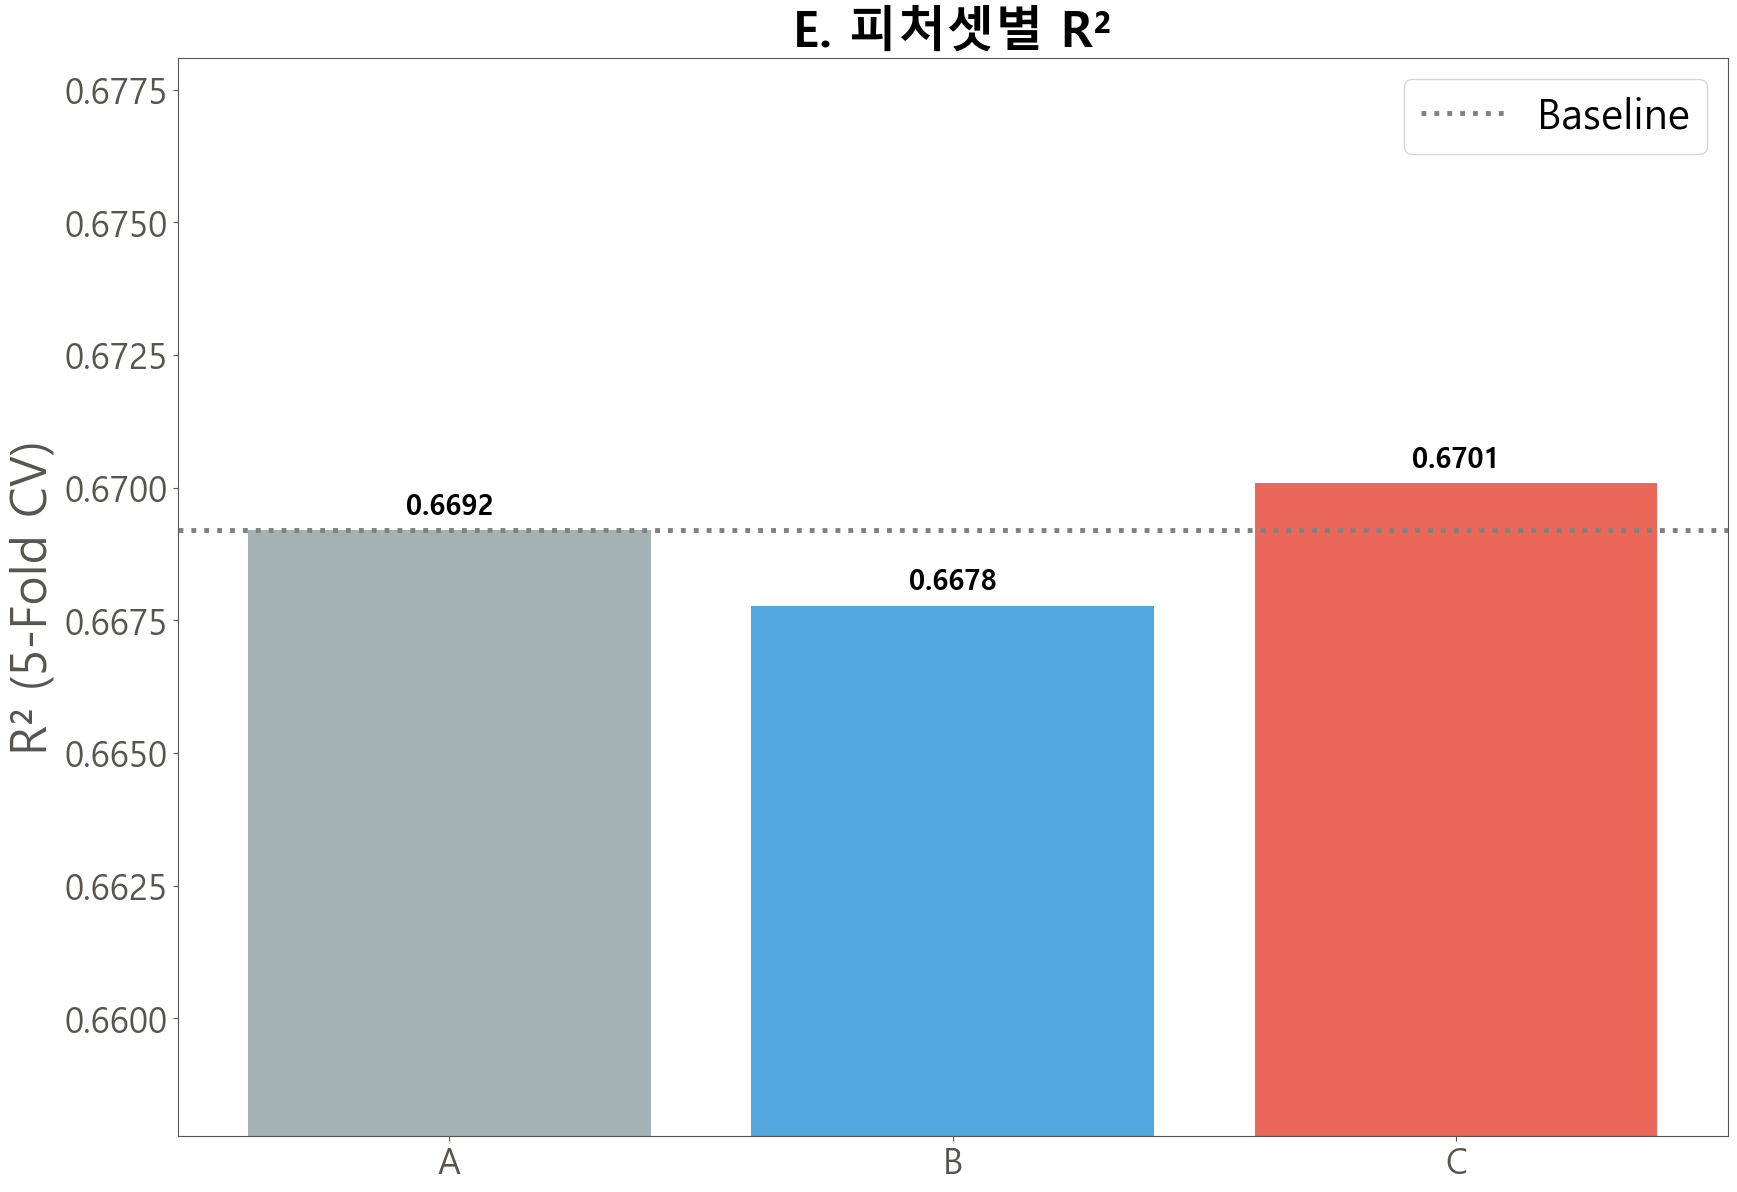

In [60]:
# 피처셋별 R2 성능비교
fig=plt.figure(figsize=(20,14))
ax=fig.add_subplot(gs[0,0])
gs=gridspec.GridSpec(1,1,figure=fig,hspace=0.5,wspace=0.38)
fl=['A','B','C']; fv=[fs_r2[k] for k in ['A','B','C']]
bars=ax.bar(fl,fv,color=['#95a5a6','#3498db','#e74c3c','#e67e22'],alpha=0.85)
ax.set_ylim(min(fv)-.01,max(fv)+.008); ax.set_ylabel('R² (5-Fold CV)',fontsize=35)
ax.set_title('E. 피처셋별 R²',fontweight='bold',fontsize=35)
for bar,val in zip(bars,fv):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.0003,
            f'{val:.4f}',ha='center',fontweight='bold',fontsize=20)
ax.tick_params(axis='x', labelsize=25)  # X축 눈금 폰트
ax.tick_params(axis='y', labelsize=25)  # Y축(피처명) 폰트
ax.axhline(fv[0],color='gray',linestyle=':',lw=3.5,label='Baseline'); ax.legend(fontsize=30)

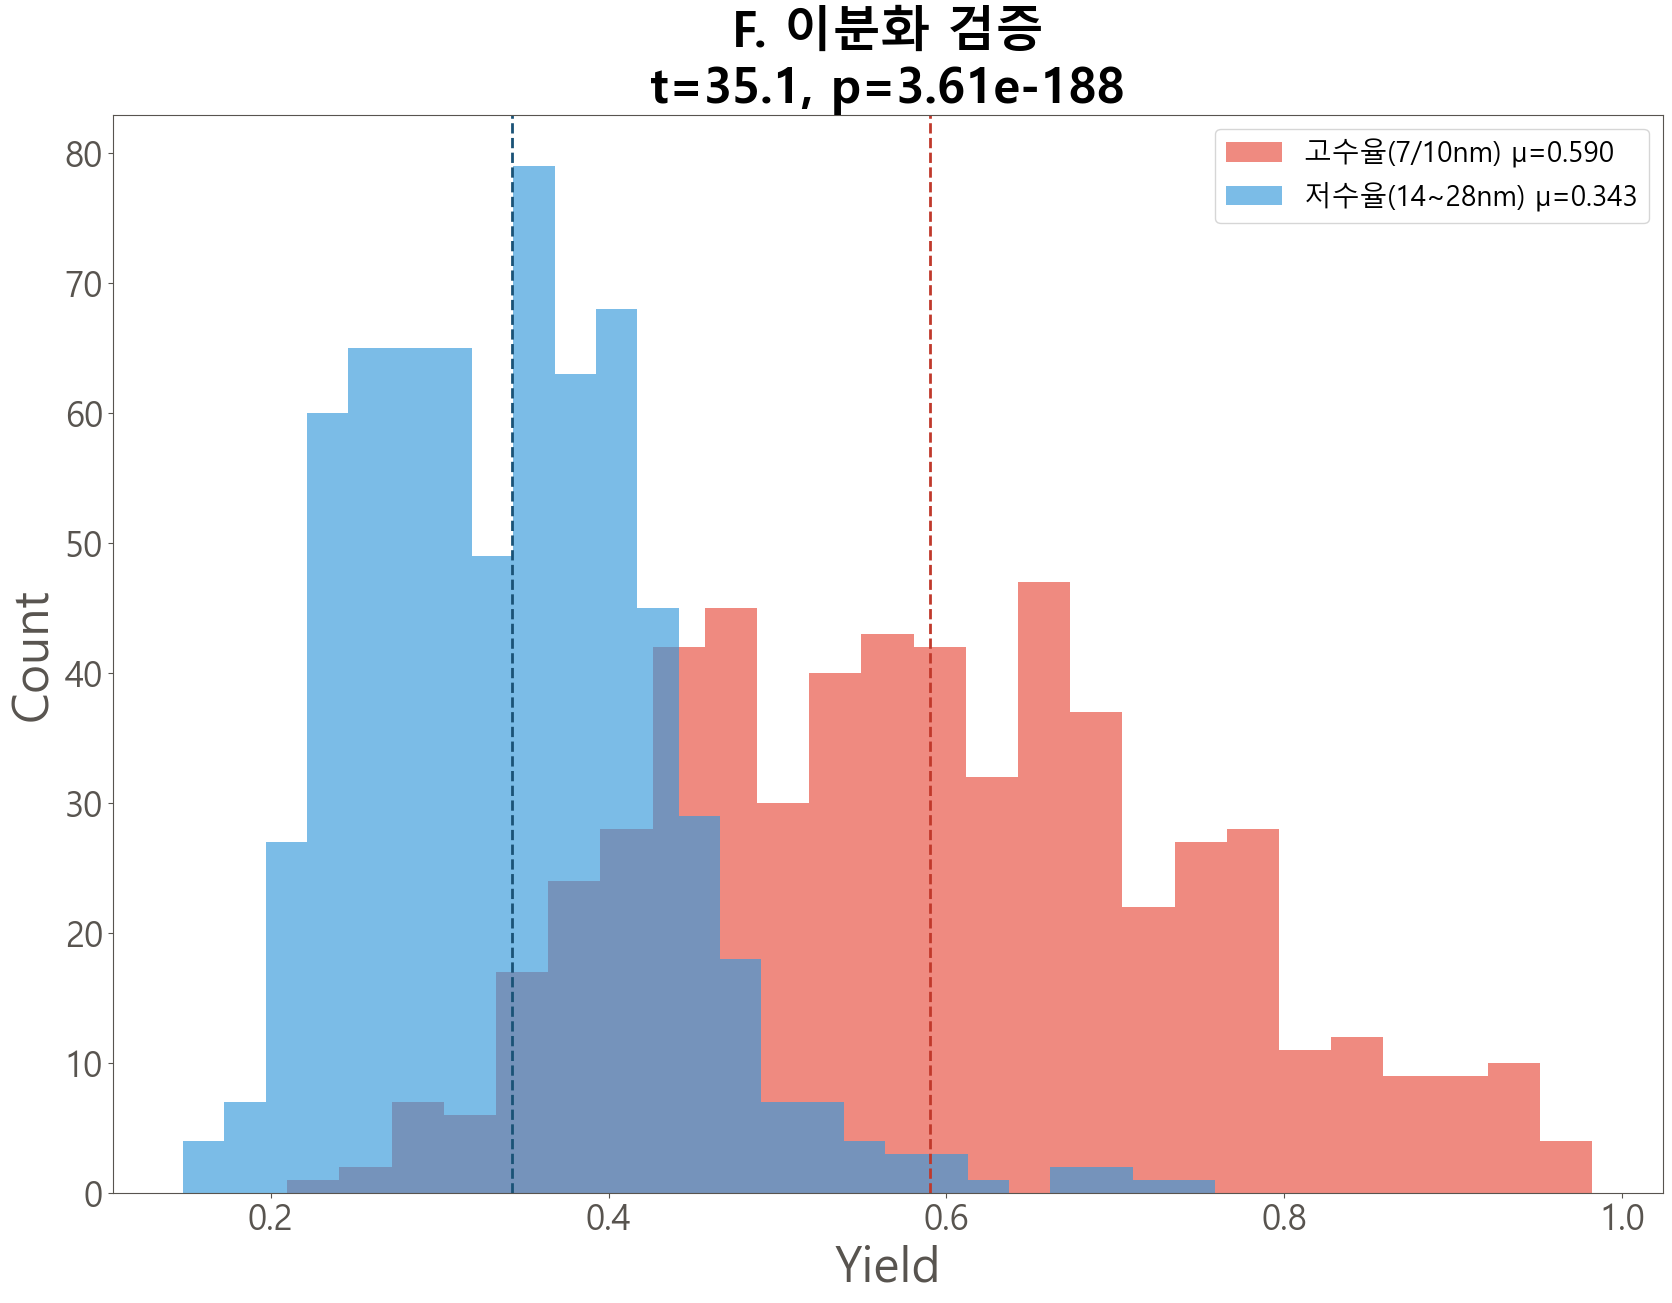

In [61]:
# F. 이분화 검증 히스토램
fig=plt.figure(figsize=(20,14))
ax=fig.add_subplot(gs[0,0])
gs=gridspec.GridSpec(1,1,figure=fig,hspace=0.5,wspace=0.38)
ax.hist(hg,bins=25,alpha=0.65,color='#e74c3c',label=f'고수율(7/10nm) μ={hg.mean():.3f}')
ax.hist(lg,bins=25,alpha=0.65,color='#3498db',label=f'저수율(14~28nm) μ={lg.mean():.3f}')
ax.axvline(hg.mean(),color='#c0392b',linestyle='--',lw=2)
ax.axvline(lg.mean(),color='#1a5276',linestyle='--',lw=2)
ax.set_xlabel('Yield',fontsize=35); ax.set_ylabel('Count',fontsize=35)
ax.tick_params(axis='x', labelsize=25)  # X축 눈금 폰트
ax.tick_params(axis='y', labelsize=25)  # Y축(피처명) 폰트
ax.set_title(f'F. 이분화 검증\nt={t_s:.1f}, p={t_p:.2e}',fontweight='bold',fontsize=35); ax.legend(fontsize=20)

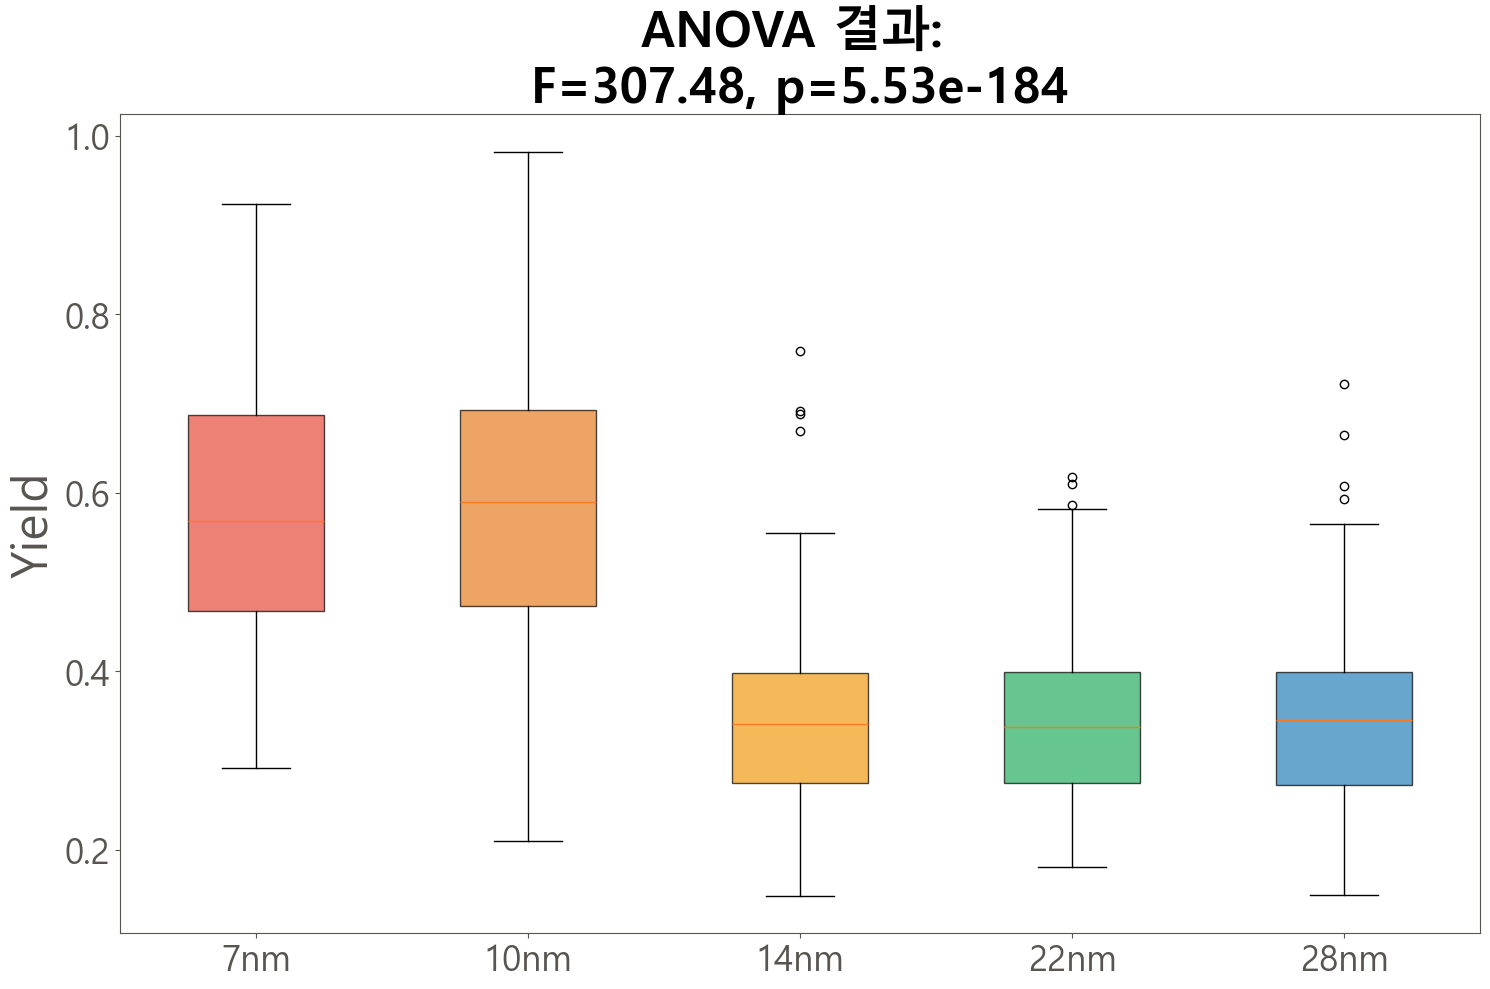

In [62]:
# 1. 시각화 영역 설정
fig, ax = plt.subplots(figsize=(15, 10))

# 2. 박스 플롯 생성
# patch_artist=True를 설정해야 박스의 색상을 변경할 수 있습니다.
bp = ax.boxplot([df[df['technology_node']==n][TARGET].values for n in TECH_NODES],
                patch_artist=True,
                labels=TECH_NODES)

# 3. 색상 적용 (violinplot의 pc.set_facecolor 방식과 유사하게 적용)
for patch, n in zip(bp['boxes'], TECH_NODES):
    patch.set_facecolor(NODE_COLORS[n])
    patch.set_alpha(0.7)
    
# 추가 스타일링
ax.set_title(f'ANOVA 결과: \nF={f_s:.2f}, p={f_p:.2e}', fontsize=35, fontweight='bold')
ax.set_ylabel('Yield', fontsize=35)
ax.tick_params(axis='x', labelsize=25)
ax.tick_params(axis='y', labelsize=25)

plt.tight_layout()
plt.show()

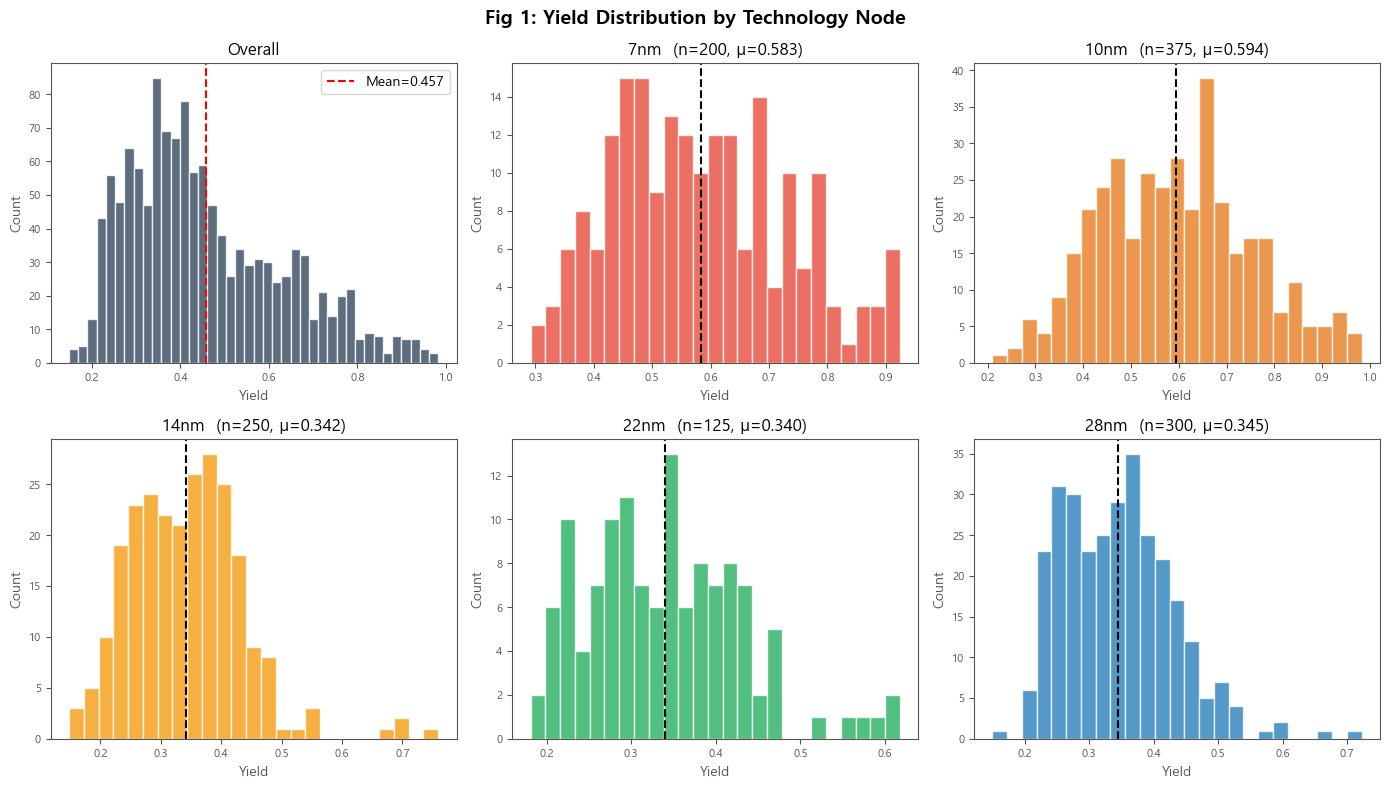

In [63]:
# ═══════════════════════════════════════════
# 1. Yield 분포 (전체 + node별)
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Fig 1: Yield Distribution by Technology Node",
             fontsize=14, fontweight="bold")

ax_all = axes[0, 0]
ax_all.hist(df[TARGET], bins=40, color="#34495e", edgecolor="white", alpha=0.8)
ax_all.axvline(df[TARGET].mean(), color="red", linestyle="--",
               label=f"Mean={df[TARGET].mean():.3f}")
ax_all.set_title("Overall"); ax_all.set_xlabel("Yield"); ax_all.set_ylabel("Count")
ax_all.legend()

for i, node in enumerate(TECH_NODES):
    ax = axes[(i + 1) // 3, (i + 1) % 3]
    sub = df[df["technology_node"] == node][TARGET]
    ax.hist(sub, bins=25, color=NODE_COLORS[node], edgecolor="white", alpha=0.8)
    ax.axvline(sub.mean(), color="black", linestyle="--", linewidth=1.5)
    ax.set_title(f"{node}  (n={len(sub)}, μ={sub.mean():.3f})")
    ax.set_xlabel("Yield"); ax.set_ylabel("Count")

plt.tight_layout()

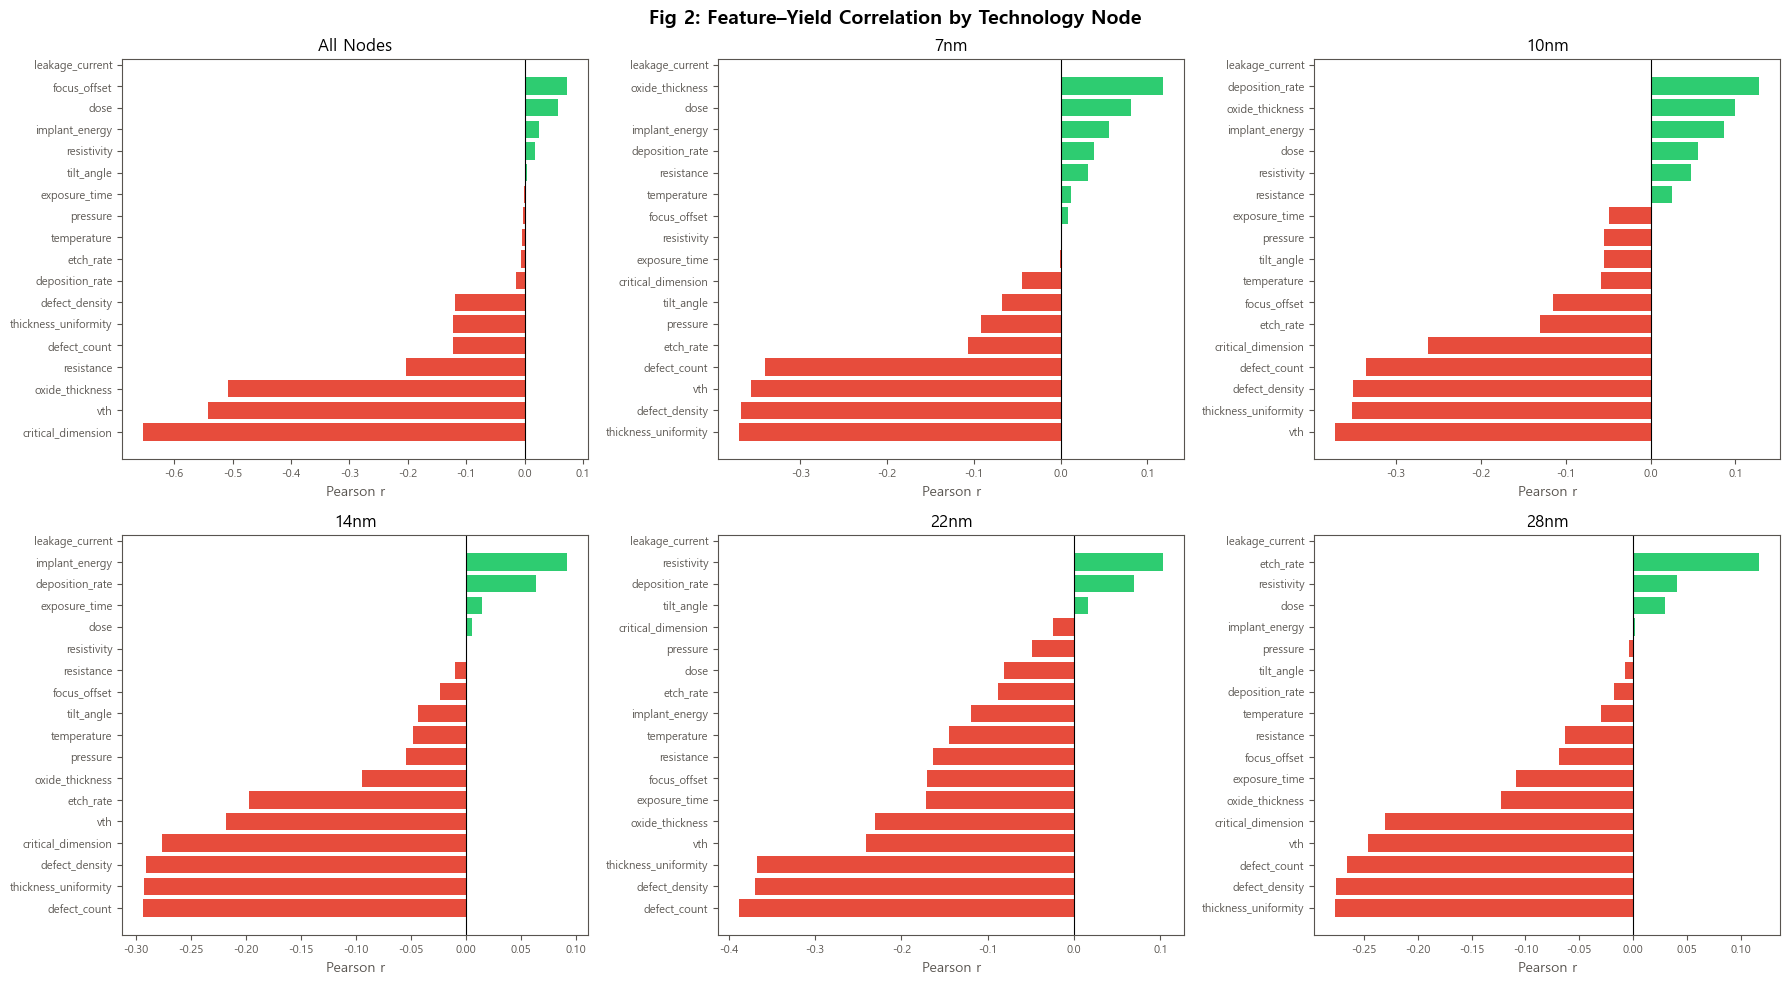

In [64]:
# ═══════════════════════════════════════════
# 2. 피처-Yield 상관계수 (node별)
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Fig 2: Feature–Yield Correlation by Technology Node",
             fontsize=14, fontweight="bold")

corr_all = (df[PROCESS_FEATURES + [TARGET]]
            .corr()[TARGET].drop(TARGET).sort_values())
axes[0, 0].barh(corr_all.index, corr_all.values,
                color=["#e74c3c" if v < 0 else "#2ecc71" for v in corr_all.values])
axes[0, 0].axvline(0, color="black", linewidth=0.8)
axes[0, 0].set_title("All Nodes"); axes[0, 0].set_xlabel("Pearson r")

for i, node in enumerate(TECH_NODES):
    ax = axes[(i + 1) // 3, (i + 1) % 3]
    sub = df[df["technology_node"] == node]
    corr = sub[PROCESS_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
    ax.barh(corr.index, corr.values,
            color=["#e74c3c" if v < 0 else "#2ecc71" for v in corr.values])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(node); ax.set_xlabel("Pearson r")

plt.tight_layout()

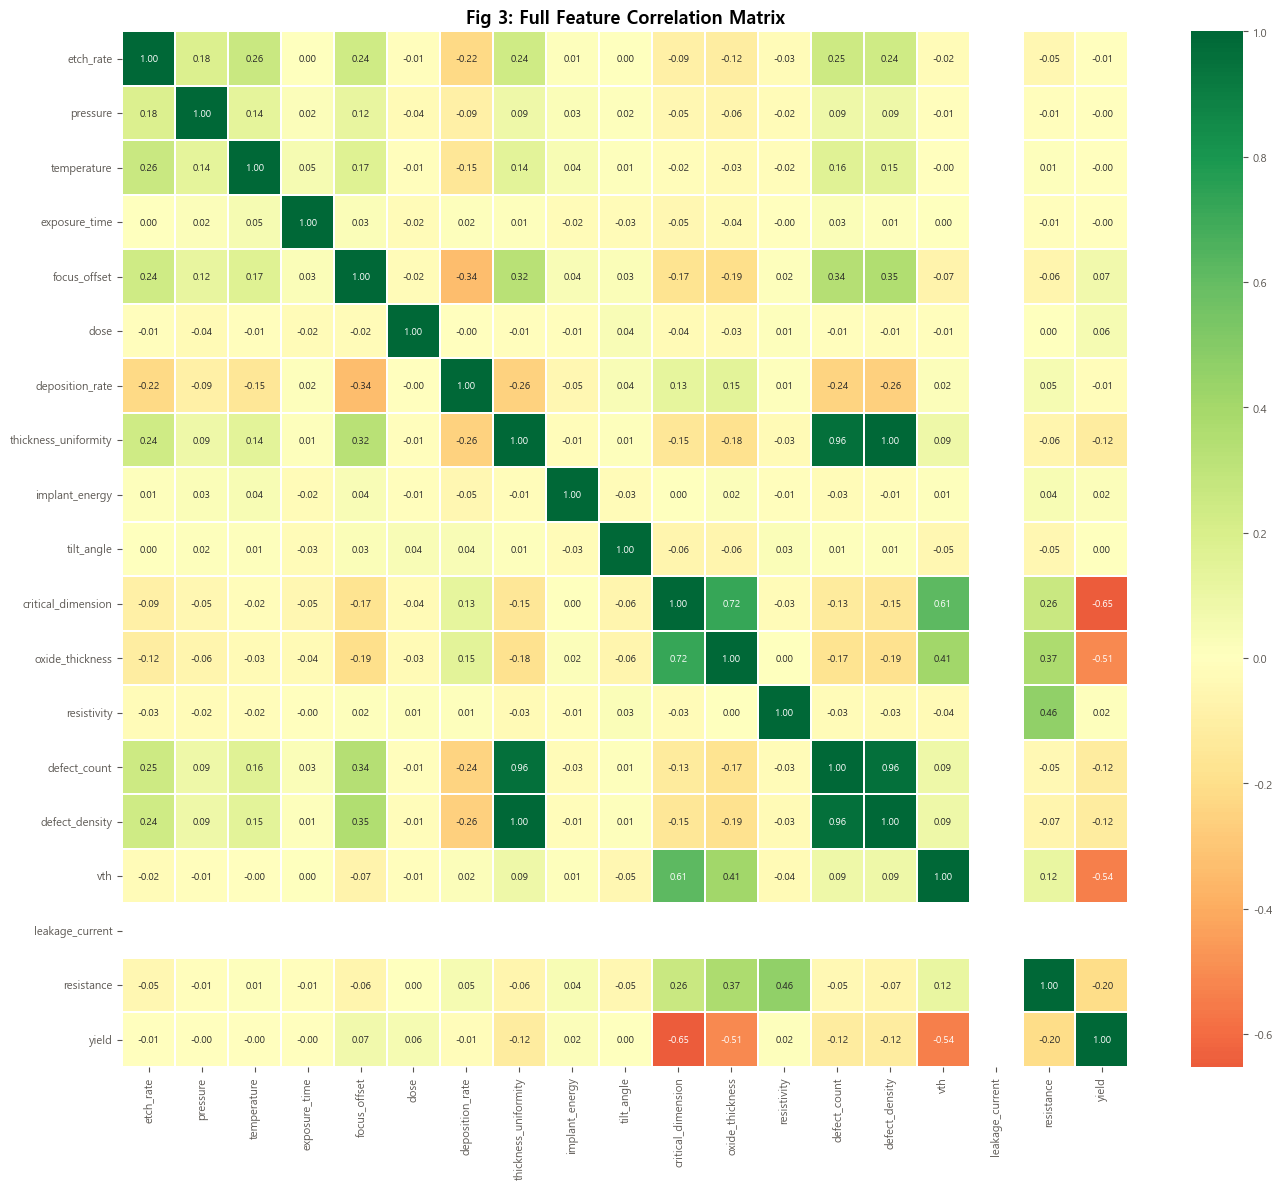

In [65]:
# ═══════════════════════════════════════════
# 3. 전체 상관행렬 히트맵
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[PROCESS_FEATURES + [TARGET]].corr()
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.3, annot_kws={"size": 7})
ax.set_title("Fig 3: Full Feature Correlation Matrix",
             fontsize=13, fontweight="bold")
plt.tight_layout()

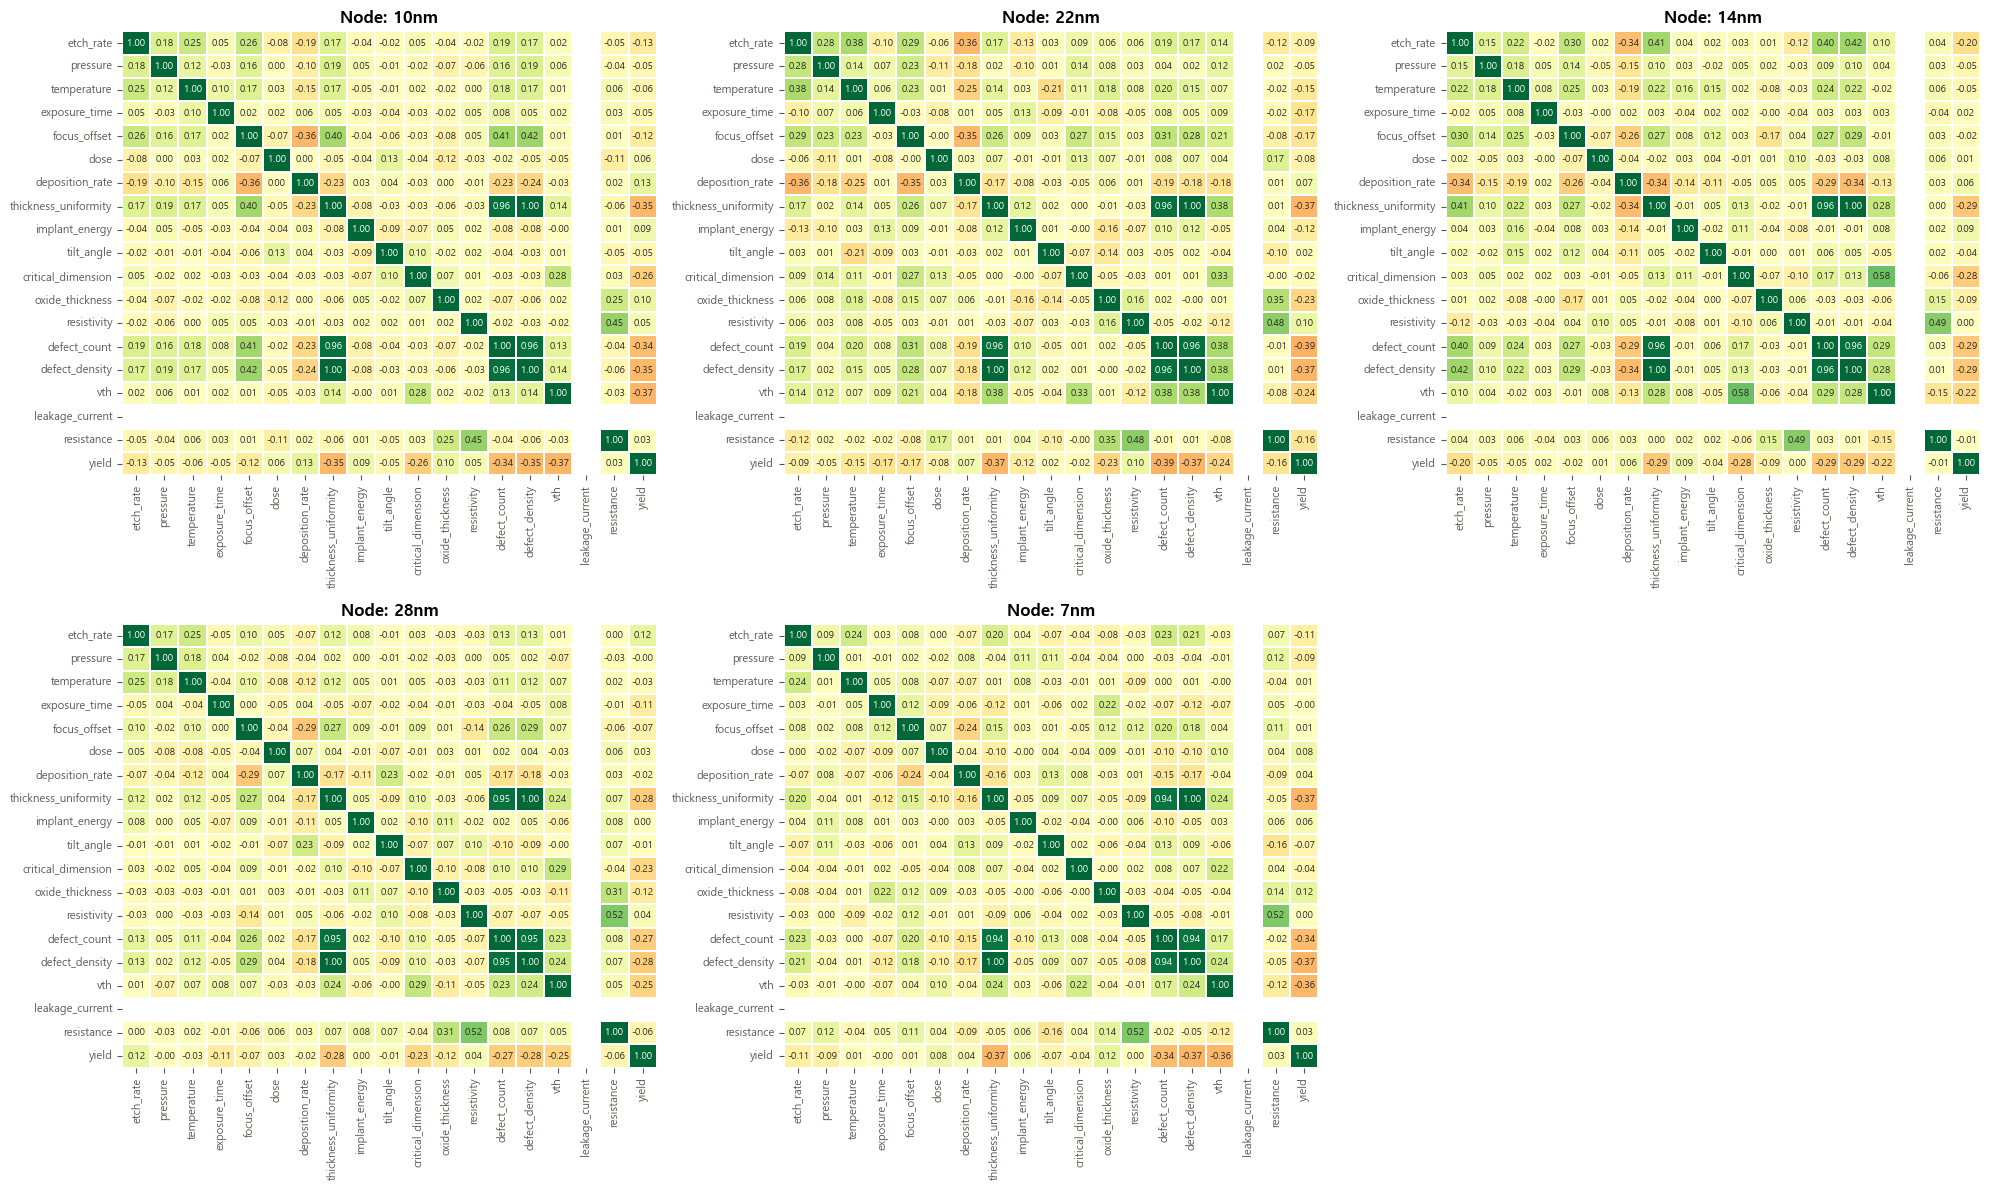

In [66]:
# 3-1. 노드별 상관행렬 히트맵 (노드별 상세 분석)
nodes = df['technology_node'].unique()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, node in enumerate(nodes):
    node_df = df[df['technology_node'] == node][PROCESS_FEATURES + [TARGET]]
    corr_node = node_df.corr()
    
    sns.heatmap(corr_node, ax=axes[i], annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, linewidths=0.3, annot_kws={"size": 7}, cbar=False)
    axes[i].set_title(f"Node: {node}", fontsize=12, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

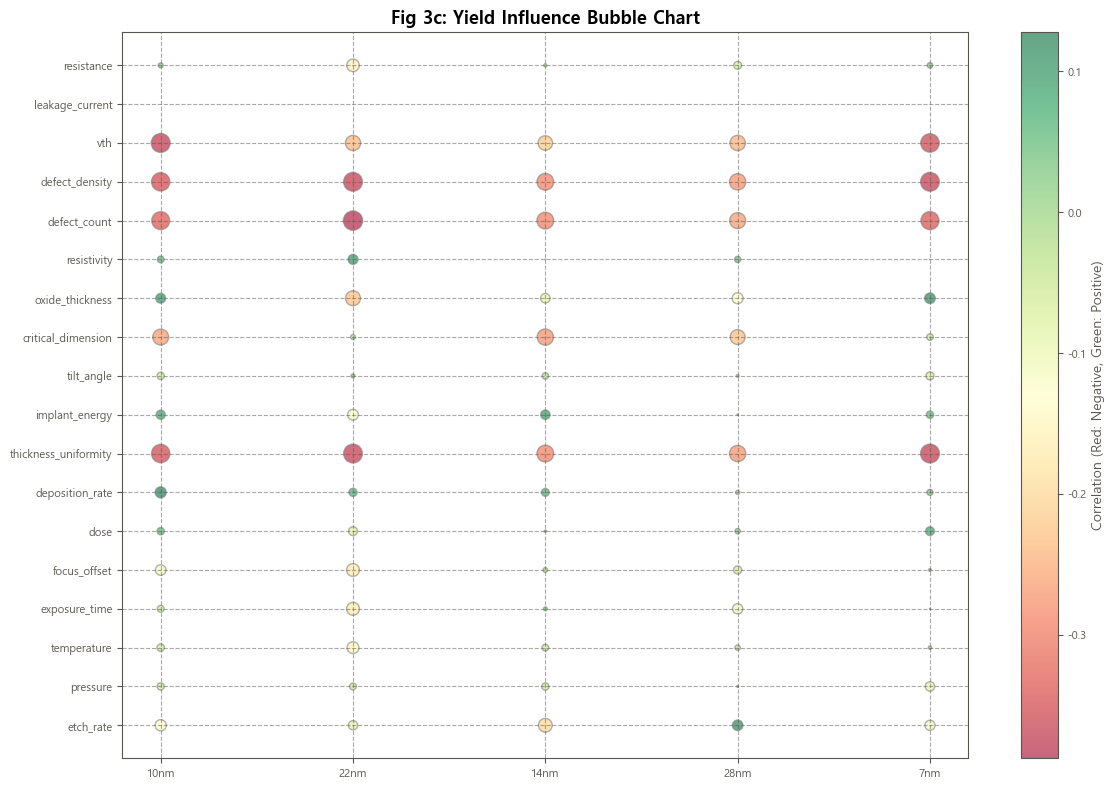

In [67]:
# ═══════════════════════════════════════════
# 3-3. 수율 영향도 '버블차트' (영향력 시각화)
# ═══════════════════════════════════════════
plt.figure(figsize=(12, 8))
bubble_data = []
numeric_features = df[PROCESS_FEATURES].select_dtypes(include=['number']).columns.tolist()
for node in df['technology_node'].unique():
    node_df = df[df['technology_node'] == node]
    # 여기서도 수치형 컬럼만 사용
    corr_series = node_df[numeric_features + [TARGET]].corr()[TARGET].drop(TARGET)
    for feature, corr in corr_series.items():
        bubble_data.append({"Node": node, "Feature": feature, "Correlation": corr})

bubble_df = pd.DataFrame(bubble_data)
plt.scatter(bubble_df["Node"], bubble_df["Feature"], 
            s=bubble_df["Correlation"].abs() * 500, 
            c=bubble_df["Correlation"], cmap="RdYlGn", alpha=0.6, edgecolors="grey")

plt.colorbar(label="Correlation (Red: Negative, Green: Positive)")
plt.title("Fig 3c: Yield Influence Bubble Chart", fontsize=13, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

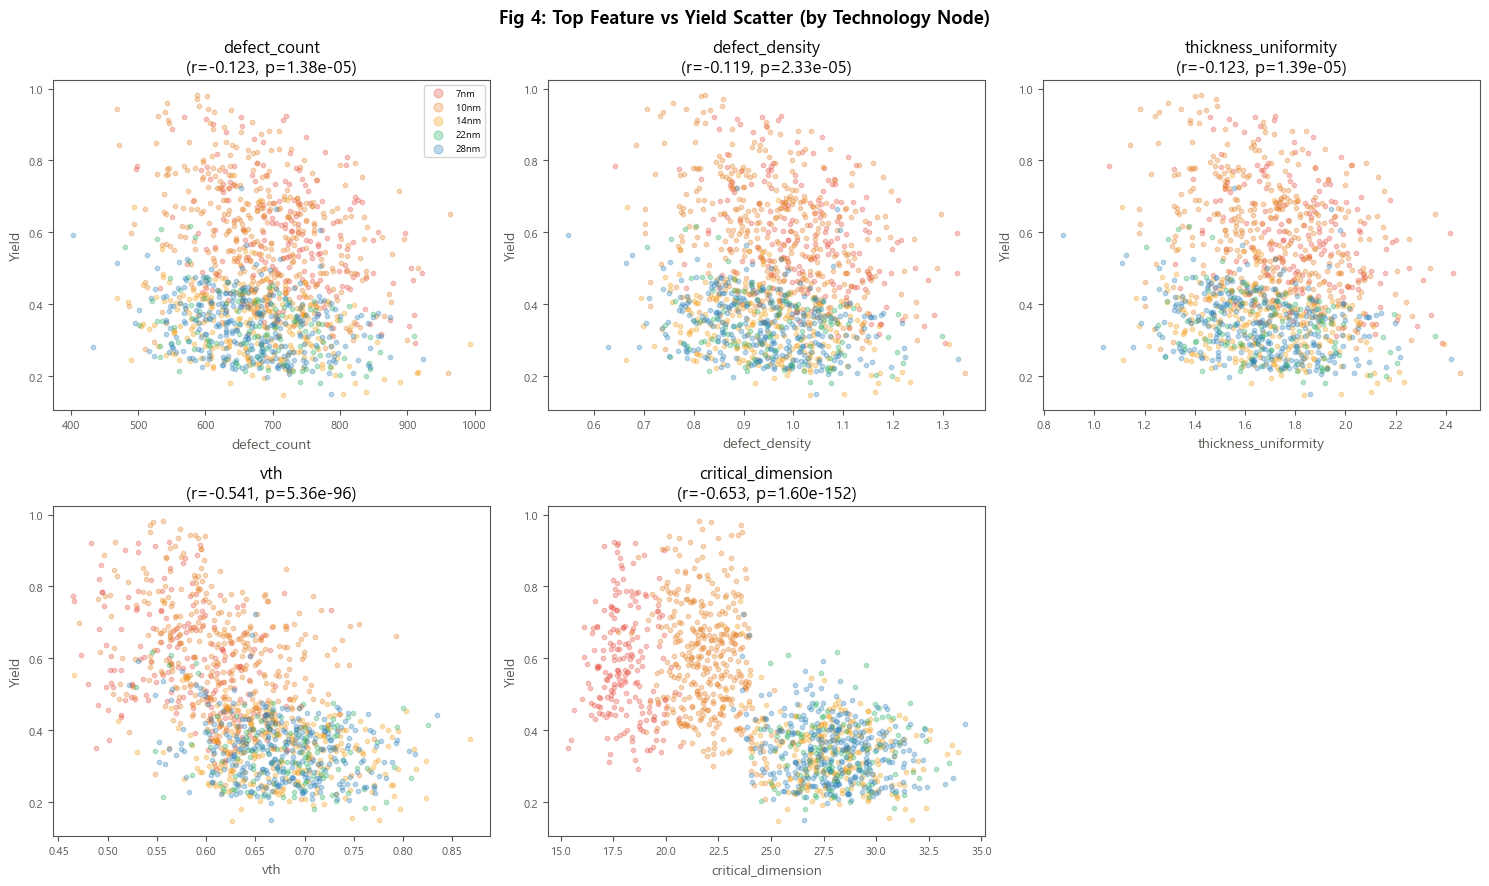

In [68]:
# ═══════════════════════════════════════════
# 4. 상위 피처 Scatter Plot
# ═══════════════════════════════════════════
top_features = ["defect_count", "defect_density", "thickness_uniformity",
                "vth", "critical_dimension"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Fig 4: Top Feature vs Yield Scatter (by Technology Node)",
             fontsize=13, fontweight="bold")
axes_flat = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes_flat[i]
    for node in TECH_NODES:
        sub = df[df["technology_node"] == node]
        ax.scatter(sub[feat], sub[TARGET], alpha=0.3, s=10,
                   color=NODE_COLORS[node], label=node)
    r, p = stats.pearsonr(df[feat], df[TARGET])
    ax.set_xlabel(feat); ax.set_ylabel("Yield")
    ax.set_title(f"{feat}\n(r={r:.3f}, p={p:.2e})")
    if i == 0:
        ax.legend(fontsize=7, markerscale=2)

axes_flat[-1].axis("off")
plt.tight_layout()

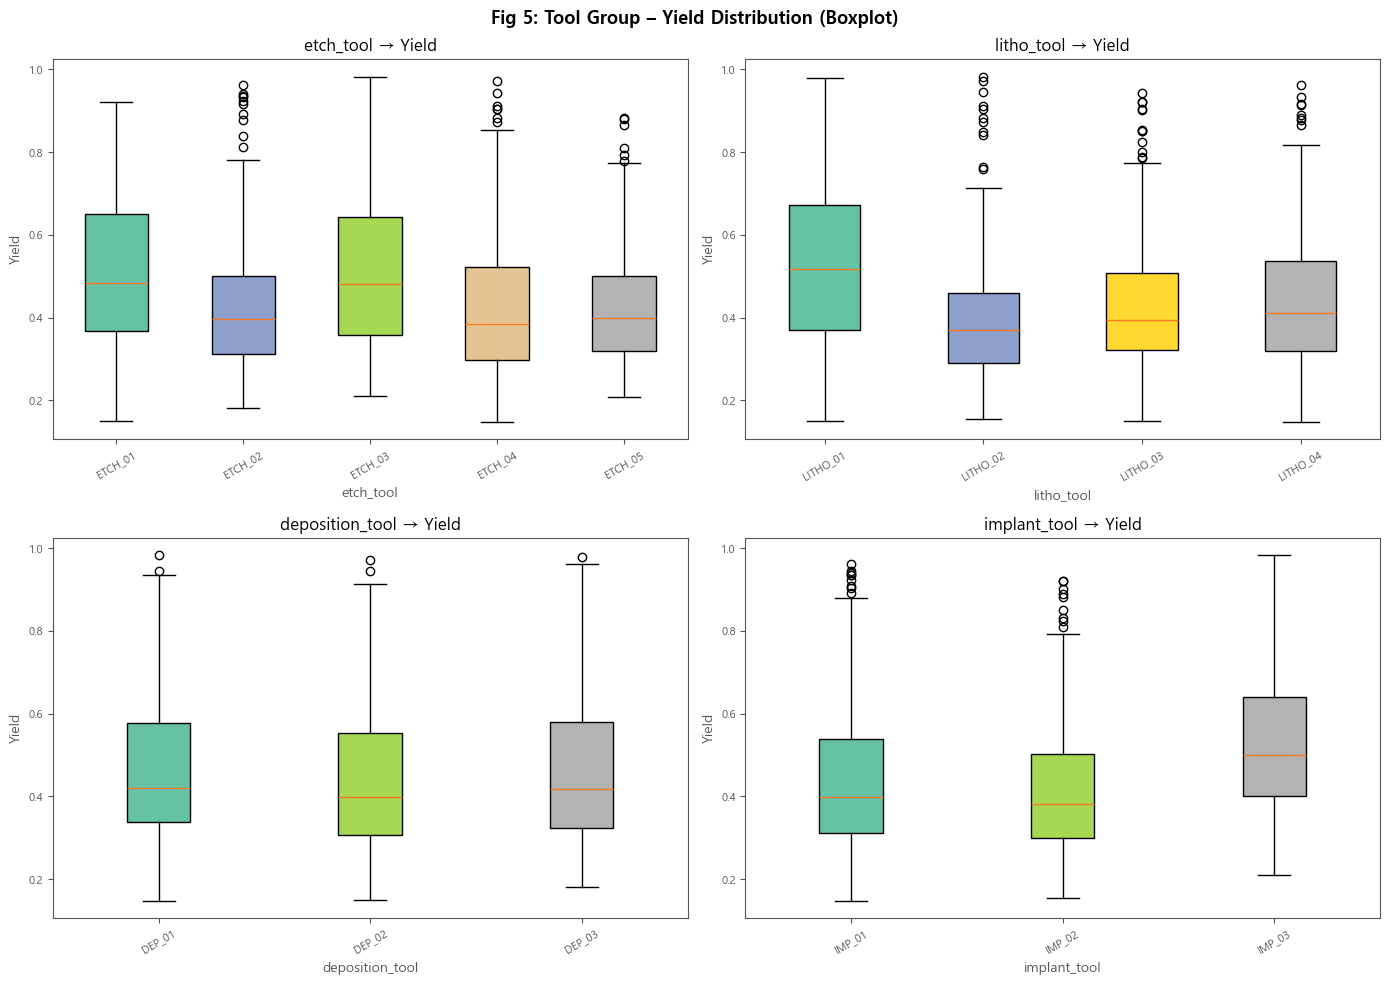

In [69]:
# ═══════════════════════════════════════════
# 5. Tool Group Boxplot
# ═══════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Fig 5: Tool Group – Yield Distribution (Boxplot)",
             fontsize=13, fontweight="bold")
tool_repr = {
    "etch_tool":       "etch_rate",
    "litho_tool":      "focus_offset",
    "deposition_tool": "thickness_uniformity",
    "implant_tool":    "implant_energy",
}
for idx, (tool_col, feat) in enumerate(tool_repr.items()):
    ax = axes[idx // 2, idx % 2]
    tools = sorted(df[tool_col].unique())
    data_by_tool = [df[df[tool_col] == t][TARGET].values for t in tools]
    bp = ax.boxplot(data_by_tool, labels=tools, patch_artist=True)
    colors_bp = plt.cm.Set2(np.linspace(0, 1, len(tools)))
    for patch, color in zip(bp["boxes"], colors_bp):
        patch.set_facecolor(color)
    ax.set_title(f"{tool_col} → Yield")
    ax.set_xlabel(tool_col); ax.set_ylabel("Yield")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

In [70]:
import missingno as msno
import matplotlib.pyplot as plt

# 매트릭스 형태로 결측치 분포 확인
msno.matrix(df, figsize=(10, 4), fontsize=10, color=(0.25, 0.45, 0.6))
plt.title("Missing Data Pattern", fontsize=16)
plt.show()

ModuleNotFoundError: No module named 'missingno'

In [71]:
import sweetviz as sv
df = pd.read_csv('./semiconductor_yield_forecasting_data.csv')
report = sv.analyze(df)
report.show_html("eda_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)


Report eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [72]:
def summarize_dataframe(df):
    """
    데이터프레임의 컬럼별 기본 정보를 깔끔한 표로 요약합니다.
    """
    summary = pd.DataFrame({
        'Data Type': df.dtypes,
        'Null (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique': df.nunique(),
        'Min': df.min(numeric_only=True),
        'Max': df.max(numeric_only=True),
        'Mean': df.mean(numeric_only=True).round(2)
    })
    
    return summary
def get_styled_summary(df):
    summary = summarize_dataframe(df)
    
    # 결측치 비율이 5% 이상인 곳에 강조색 적용
    return summary.style.background_gradient(subset=['Null (%)'], cmap='Reds') \
                  .format({'Null (%)': '{:.2f}%'}) \
                  .set_caption("DataFrame Basic Info Summary")
df_summary = summarize_dataframe(df)
get_styled_summary(df)

,Data Type,Null (%),Unique,Min,Max,Mean
critical_dimension,float64,0.00%,1250,15.337494,34.232696,24.610000
defect_count,int64,0.00%,359,403.000000,993.000000,682.780000
defect_density,float64,0.00%,1250,0.547276,1.344248,0.960000
deposition_rate,float64,0.00%,1250,1.542779,2.259813,1.900000
deposition_tool,str,0.00%,3,nan,nan,nan
dose,float64,0.00%,1250,970332469312592.750000,1033009718943015.250000,1000095189102549.500000
etch_rate,float64,0.00%,1250,3.304931,3.935599,3.620000
etch_tool,str,0.00%,5,nan,nan,nan
exposure_time,float64,0.00%,1250,1.350315,1.670403,1.500000
focus_offset,float64,0.00%,1250,0.008577,0.051468,0.030000


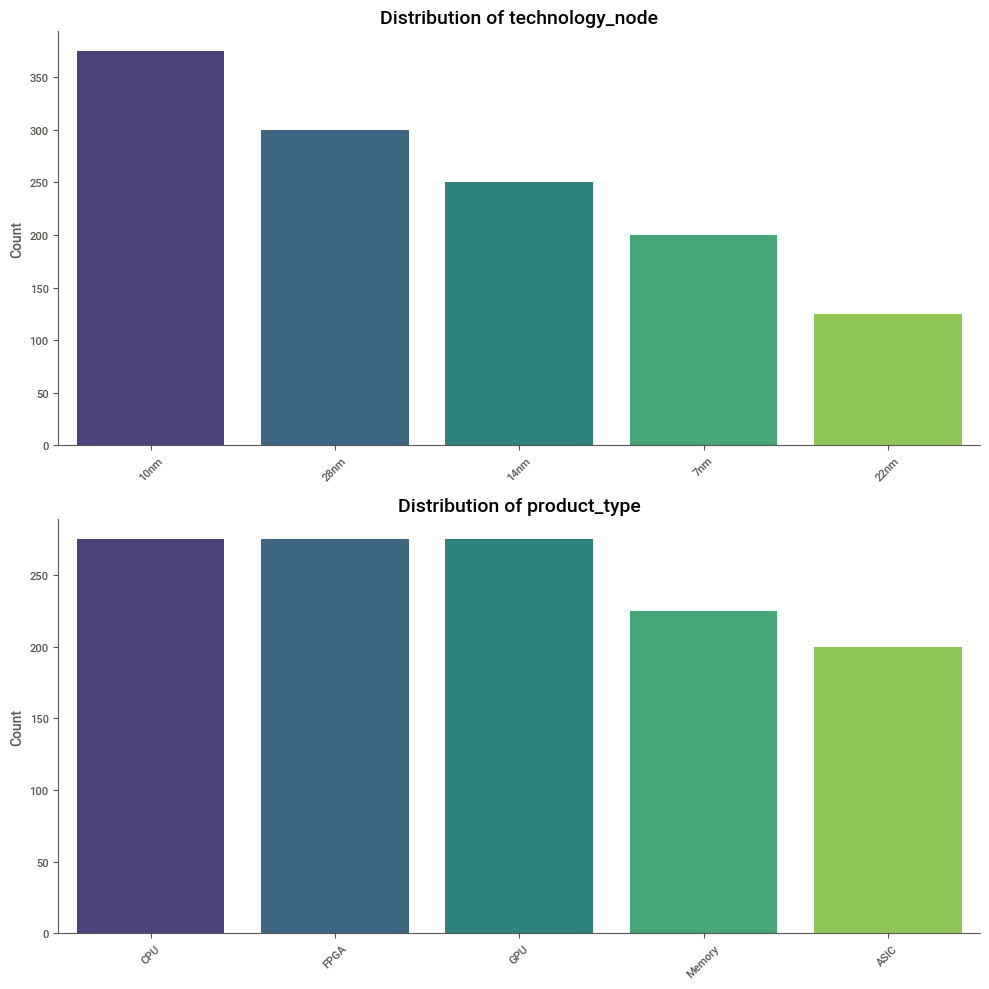

In [73]:
def plot_categorical_distribution(df, cat_cols):
    """
    범주형 컬럼들의 샘플 수를 시각화하는 함수
    """
    n = len(cat_cols)
    fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))
    
    # 컬럼이 1개일 경우를 대비한 조정
    if n == 1: axes = [axes]
        
    for i, col in enumerate(cat_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", order=df[col].value_counts().index)
        axes[i].set_title(f"Distribution of {col}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")
        
        # Minimalism: 불필요한 테두리 제거
        sns.despine(ax=axes[i])
        
        # 레이블이 길 경우 회전
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# 사용 예시
categorical_features = ['technology_node','product_type']
plot_categorical_distribution(df, categorical_features)

In [87]:
def section2(df, FS):
    banner(f"§2  Phase 1 — 베이스라인 스크리닝 (27개 모델)")
    #FS_C에 대한 Scaling 데이터 준비
    X=df[FS['C']].values; y=df[TARGET].values; Xs=StandardScaler().fit_transform(X)

    # RANSAC: base_estimator 없으면 LinearRegression 사용
    # https://blog.naver.com/samsjang/221003286930 참고
    # Random sample consensus
    # sampling을 random으로 추출해서 Ridge로 회귀 모델을 만들고 오차가 적은 데이터(정상치)가 가장 많은 모델을 최종 선택하는 방식
    ransac = RANSACRegressor(estimator=Ridge(alpha=1.0),
                             min_samples=0.5, random_state=RANDOM_STATE)

    xgb_name = BOOST_LIBS['xgb_name']
    lgb_name = BOOST_LIBS['lgb_name']
    cb_name  = BOOST_LIBS['cb_name']

    # 모델이름 : (모델객체, 스케일링여부, 카테고리) 순서대로 기재함
    # Tree기반은 StandardScaler가 필요없음.
    MODELS = {
        # ── 선형 (6) ───────────────────────────────────────────
        'Linear Regression':    (LinearRegression(),                                      True,  'linear'),
        'Ridge':                (Ridge(alpha=1.0),                                        True,  'linear'),
        'Lasso':                (Lasso(alpha=0.001,max_iter=5000),                        True,  'linear'),
        'ElasticNet':           (ElasticNet(alpha=0.001,l1_ratio=0.5,max_iter=5000),      True,  'linear'),
        'PLS (n=8)':           (PLSRegression(n_components=8),                           True,  'linear'),
        'PCR (PCA+Ridge)':     (make_pipeline(StandardScaler(), PCA(n_components=0.95), Ridge()), True, 'linear'),
        
        # ── 이상치 강건 (6) ────────────────────────────────────
        'Huber Regressor':      (HuberRegressor(epsilon=1.35,max_iter=300),               True,  'robust'),
        'Bayesian Ridge':       (BayesianRidge(),                                         True,  'robust'),
        'TheilSen':             (TheilSenRegressor(random_state=RANDOM_STATE,
                                                   max_subpopulation=500),                True,  'robust'),
        'Kernel Ridge (RBF)':   (KernelRidge(alpha=1.0,kernel='rbf'),                     True,  'robust'),
        'RANSAC + Ridge':       (ransac,                                                  True,  'robust'),
        'Quantile (Q=0.1)':     (QuantileRegressor(quantile=0.1, alpha=0),                True,  'robust'),
        
        # ── 비선형 및 해석가능 (5) ────────────────────────────────
        'SVR (RBF)':           (SVR(kernel='rbf',C=1.0),                                 True,  'nonlinear'),
        'SVR (POLY)':          (SVR(kernel='poly',C=1.0),                                True,  'nonlinear'),
        'NuSVR':               (NuSVR(kernel='rbf',nu=0.5),                              True,  'nonlinear'),
        'KNN (k=5)':           (KNeighborsRegressor(n_neighbors=5),                      True,  'nonlinear'),
        'MLP (128-64)':        (MLPRegressor(hidden_layer_sizes=(128,64),max_iter=500,
                                             random_state=RANDOM_STATE),                  True,  'nonlinear'),
        
        # ── 단일 트리 (1) ──────────────────────────────────────
        'Decision Tree':        (DecisionTreeRegressor(max_depth=8,
                                                       random_state=RANDOM_STATE),       False, 'tree'),
        
        # ── 앙상블 (4) ─────────────────────────────────────────
        'Bagging (DT)':         (BaggingRegressor(
                                    estimator=DecisionTreeRegressor(max_depth=6),
                                    n_estimators=50,random_state=RANDOM_STATE,
                                    n_jobs=-1),                                           False, 'ensemble'),
        'Random Forest':        (RandomForestRegressor(n_estimators=100,
                                    random_state=RANDOM_STATE,n_jobs=-1),                 False, 'ensemble'),
        'Extra Trees':          (ExtraTreesRegressor(n_estimators=100,
                                    random_state=RANDOM_STATE,n_jobs=-1),                 False, 'ensemble'),
        'AdaBoost':             (AdaBoostRegressor(n_estimators=100,
                                    random_state=RANDOM_STATE),                           False, 'ensemble'),
        
        # ── 부스팅 (5) ─────────────────────────────────────────
        'Gradient Boosting':    (GradientBoostingRegressor(n_estimators=100,
                                    random_state=RANDOM_STATE),                           False, 'boosting'),
        'HistGradientBoost':    (HistGradientBoostingRegressor(random_state=RANDOM_STATE), False, 'boosting'),
        xgb_name:               (BOOST_LIBS['xgb'],                                       False, 'boosting'),
        lgb_name:               (BOOST_LIBS['lgb'],                                       False, 'boosting'),
        cb_name:                (BOOST_LIBS['cb'],                                        False, 'boosting'),
    }

    print(f"\n  라이브러리 상태:")
    print(f"    XGBoost : {xgb_name}")
    print(f"    LightGBM: {lgb_name}")
    print(f"    CatBoost: {cb_name}")
    print(f"\n  {'Model':<30s}  {'R² mean':>8s}  {'R² std':>7s}  {'RMSE':>7s}  {'Cat':>10s}")
    print("  "+"─"*72)

    p1={}
    for name,(model,use_std,cat) in MODELS.items():
        Xu=Xs if use_std else X
        try:
            cv=cross_validate(model,Xu,y,cv=kf,
                              scoring=['r2','neg_mean_squared_error','neg_mean_absolute_error'],
                              n_jobs=-1)
            r2m=float(cv['test_r2'].mean()); r2s=float(cv['test_r2'].std())
            rmse=float(np.sqrt(-cv['test_neg_mean_squared_error'].mean()))
            mae=float(-cv['test_neg_mean_absolute_error'].mean())
        except Exception as e:
            print(f"  ⚠️ {name} 실패: {e}")
            r2m=r2s=rmse=mae=0.0
        p1[name]=dict(R2_mean=r2m,R2_std=r2s,RMSE=rmse,MAE=mae,category=cat,use_std=use_std)
        print(f"  {name:<30s}  {r2m:>8.4f}  {r2s:>7.4f}  {rmse:>7.4f}  {cat:>10s}")

    p1_df=(pd.DataFrame(p1).T.reset_index().rename(columns={'index':'model'})
           .sort_values('R2_mean',ascending=False).reset_index(drop=True))

    fig,axes=plt.subplots(1,3,figsize=(22,10))
    fig.suptitle(f'§2. Phase 1 — 베이스라인 스크리닝 ({len(MODELS)}개 모델, {CV_FOLDS}-Fold CV)\n'
                 f'{xgb_name} | {lgb_name} | {cb_name}',
                 fontsize=12,fontweight='bold')

    colors_p1=[CAT_COLORS.get(p1_df.loc[p1_df['model']==m,'category'].values[0],'#95a5a6')
               for m in p1_df['model']]
    bars=axes[0].barh(p1_df['model'],p1_df['R2_mean'].astype(float),color=colors_p1,alpha=0.85)
    axes[0].errorbar(p1_df['R2_mean'].astype(float),range(len(p1_df)),
                     xerr=p1_df['R2_std'].astype(float),fmt='none',color='black',capsize=3,lw=1.5)
    axes[0].invert_yaxis(); axes[0].axvline(0.6,color='orange',linestyle='--',lw=1.5)
    axes[0].legend(handles=[mpatches.Patch(fc=v,label=k) for k,v in CAT_COLORS.items()],
                   fontsize=8,loc='lower right')
    axes[0].set_xlabel('R²'); axes[0].set_title('R² 비교',fontweight='bold')
    for bar,val in zip(bars,p1_df['R2_mean'].astype(float)):
        axes[0].text(val+.001,bar.get_y()+bar.get_height()/2,f'{val:.4f}',va='center',fontsize=7)

    ps=p1_df.sort_values('RMSE')
    bars2=axes[1].barh(ps['model'],ps['RMSE'].astype(float),
                       color=[CAT_COLORS.get(ps.loc[ps['model']==m,'category'].values[0],'#95a5a6')
                              for m in ps['model']],alpha=0.85)
    axes[1].invert_yaxis(); axes[1].set_xlabel('RMSE'); axes[1].set_title('RMSE 비교',fontweight='bold')
    for bar,val in zip(bars2,ps['RMSE'].astype(float)):
        axes[1].text(val+.0003,bar.get_y()+bar.get_height()/2,f'{val:.4f}',va='center',fontsize=7)

    cat_avg=(p1_df.groupby('category')['R2_mean']
             .apply(lambda s:s.astype(float).mean()).sort_values(ascending=False))
    bars3=axes[2].bar(cat_avg.index,cat_avg.values,
                      color=[CAT_COLORS.get(c,'#95a5a6') for c in cat_avg.index],alpha=0.85)
    axes[2].set_ylabel('평균 R²'); axes[2].set_title('카테고리별 평균 R²',fontweight='bold')
    for bar,val in zip(bars3,cat_avg.values):
        axes[2].text(bar.get_x()+bar.get_width()/2,bar.get_height()+.003,
                     f'{val:.4f}',ha='center',fontweight='bold',fontsize=10)

    save_fig(fig,'sec2_phase1_screening')
    save_csv(p1_df,'phase1_results')
    save_json({'results':p1,'cat_avg':cat_avg.to_dict(),
               'lib_status':{'xgb':xgb_name,'lgb':lgb_name,'cb':cb_name}},'sec2_phase1')
    return p1

def section2_1(df, FS):
    banner(f"§2  Phase 1 — 베이스라인 스크리닝 (누수 방지 파이프라인 적용)")
    
    # Target과 Features 정의
    X = df[FS['C']]
    y = df[TARGET]
    
    # K-Fold 정의 (상단에서 정의된 kf 사용 가정)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    # RANSAC 정의
    ransac = RANSACRegressor(estimator=Ridge(alpha=1.0), min_samples=0.5, random_state=RANDOM_STATE)

    # 모델 정의 (Pipeline 도입: 스케일링이 필요한 모델은 자동으로 내부에서 처리)
    MODELS = {
        'Linear Regression': (LinearRegression(), True),
        'Ridge': (Ridge(alpha=1.0), True),
        'Lasso': (Lasso(alpha=0.001, max_iter=5000), True),
        'ElasticNet': (ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000), True),
        'PLS (n=8)': (PLSRegression(n_components=8), True),
        'PCR (PCA+Ridge)': (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)), ('ridge', Ridge())]), False),
        'Huber Regressor': (HuberRegressor(epsilon=1.35, max_iter=300), True),
        'Bayesian Ridge': (BayesianRidge(), True),
        'TheilSen': (TheilSenRegressor(random_state=RANDOM_STATE, max_subpopulation=500), True),
        'Kernel Ridge (RBF)': (KernelRidge(alpha=1.0, kernel='rbf'), True),
        'RANSAC + Ridge': (ransac, True),
        'Quantile (Q=0.1)': (QuantileRegressor(quantile=0.1, alpha=0), True),
        'SVR (RBF)': (SVR(kernel='rbf', C=1.0), True),
        'SVR (POLY)': (SVR(kernel='poly', C=1.0), True),
        'NuSVR': (NuSVR(kernel='rbf', nu=0.5), True),
        'KNN (k=5)': (KNeighborsRegressor(n_neighbors=5), True),
        'MLP (128-64)': (MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=RANDOM_STATE), True),
        'Decision Tree': (DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE), False),
        'Bagging (DT)': (BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6), n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1), False),
        'Random Forest': (RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), False),
        'Extra Trees': (ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), False),
        'AdaBoost': (AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE), False),
        'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE), False),
        'HistGradientBoost': (HistGradientBoostingRegressor(random_state=RANDOM_STATE), False),
        BOOST_LIBS['xgb_name']: (BOOST_LIBS['xgb'], False),
        BOOST_LIBS['lgb_name']: (BOOST_LIBS['lgb'], False),
        BOOST_LIBS['cb_name']: (BOOST_LIBS['cb'], False),
    }

    print(f"\n {'Model':<30s}  {'R² mean':>8s}  {'R² std':>7s}  {'RMSE':>7s}")
    print(" "+"─"*60)

    p1 = {}
    for name, (model, use_std) in MODELS.items():
        # Pipeline 구축: 스케일링이 필요한 경우만 StandardScaler 추가
        if use_std:
            pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
        else:
            pipeline = Pipeline([('model', model)])
            
        try:
            cv = cross_validate(pipeline, X, y, cv=kf,
                                scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
                                n_jobs=-1)
            r2m, r2s = cv['test_r2'].mean(), cv['test_r2'].std()
            rmse = np.sqrt(-cv['test_neg_mean_squared_error'].mean())
            mae = -cv['test_neg_mean_absolute_error'].mean()
        except Exception as e:
            print(f" ⚠️ {name} 실패: {e}")
            r2m = r2s = rmse = mae = 0.0
        
        # 카테고리 매핑 로직은 기존 코드 활용 (생략됨)
        p1[name] = dict(R2_mean=r2m, R2_std=r2s, RMSE=rmse, MAE=mae)
        print(f"  {name:<30s}  {r2m:>8.4f}  {r2s:>7.4f}  {rmse:>7.4f}")

    # 결과 저장 및 시각화 코드는 기존 로직을 유지...
    # (이후 시각화 및 파일 저장 로직은 기존 함수와 동일하게 이어집니다)
    return p1

p1_results=section2(df,FS)
p1_results_re = section2_1(df,FS)


═════════════════════════════════════════════════════════════════
  §2  Phase 1 — 베이스라인 스크리닝 (27개 모델)
═════════════════════════════════════════════════════════════════

  라이브러리 상태:
    XGBoost : HistGBM (≈XGBoost 대안)
    LightGBM: HistGBM (≈LightGBM 대안)
    CatBoost: HistGBM (≈CatBoost 대안)

  Model                            R² mean   R² std     RMSE         Cat
  ────────────────────────────────────────────────────────────────────────
  Linear Regression                 0.5686   0.0346   0.1149      linear
  Ridge                             0.5697   0.0323   0.1148      linear
  Lasso                             0.5700   0.0281   0.1147      linear
  ElasticNet                        0.5697   0.0282   0.1147      linear
  PLS (n=8)                         0.5677   0.0295   0.1150      linear
  PCR (PCA+Ridge)                   0.5521   0.0249   0.1171      linear
  Huber Regressor                   0.5636   0.0326   0.1156      robust
  Bayesian Ridge                    0.5695   0.0

In [ ]:
def compare_model_results(dict_a, dict_b, threshold=0.01):
    """
    두 모델 결과 딕셔너리를 비교하여 R2_mean 오차가 threshold(1%) 이상인 모델을 출력
    """
    diff_report = []
    
    # 딕셔너리의 모든 모델 키를 순회
    for model_name in dict_a.keys():
        if model_name in dict_b:
            val_a = dict_a[model_name]['R2_mean']
            val_b = dict_b[model_name]['R2_mean']
            
            # 절대값 기준으로 1% 이상 차이가 나는지 계산
            # (val_a - val_b) / val_a 가 1% 이상인 경우
            relative_error = abs(val_a - val_b) / abs(val_a)
            
            if relative_error >= threshold:
                diff_report.append({
                    'Model': model_name,
                    'Result_A': f"{val_a:.4f}",
                    'Result_B': f"{val_b:.4f}",
                    'Error': f"{relative_error:.2%}"
                })
    
    return pd.DataFrame(diff_report)

# 사용 예시
diff_df = compare_model_results(p1_results, p1_results_re)
print(diff_df)

Model Result_A Result_B  Error
0    SVR (POLY)   0.2971   0.2915  1.88%
1  MLP (128-64)   0.2397   0.2370  1.13%

          Model Result_A Result_B  Error
0    SVR (POLY)   0.2971   0.2915  1.88%
1  MLP (128-64)   0.2397   0.2370  1.13%


In [ ]:
CV_FOLDS     = 5
RANDOM_STATE = 42
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)